# インド株 ファクター検証 — Step 6: AI スコア・オルタナティブファクター

`factor/ai/`（AIスコア）と `factor/alt/`（38ファクター）の基本特性とパフォーマンスを、
コアファクターと同じ物差し（Blom → 5分位 / IC）で評価する。

## タイミング規約

| データ | 時点 t のスコア | 根拠 |
|---|---|---|
| alt | `alt/{id}/{t}.pkl` のうち **`effective_yyyymmdd` ≤ t の月末** のレコード（銘柄ごとに発効日最新） | 発効日ベースの PIT（README / `docs/tutorial` 0.3） |
| ai | 月 t 内で**最後に観測された日次値**（月末スナップショット） | 日次系列の月次化 |

評価リターンはこれまで同様 `barra/rtn/{t}.pkl` の `lag == 1`（翌月）。

## 見るもの

1. **基本特性**: カバレッジ（対ユニバース / 対ベンチマーク）・離散度・順位の持続性
2. **パフォーマンス**: Q5−Q1 / Q5 の年率超過（縦棒）、IC
3. **相関構造**: スコアの順位相関・Q5 重複率（グループ色帯つき）
4. **AI スコアの深掘り**: IC 時系列・減衰・分位ダッシュボード
5. **rev*_gdb と core の rev\* の突き合わせ**

In [1]:
%matplotlib inline
%config InlineBackend.figure_format = "retina"

import sys
from pathlib import Path

import numpy as np
import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

import factorlab as fl

fl.plotting.set_style()
pd.set_option("display.width", 250, "display.max_columns", 40, "display.float_format", lambda v: f"{v:,.3f}")

START, END = 201301, 202607   # alt の最古 (NAM ESG: 201302) に合わせる。TVL のみ後段で 200701 から再確認
Q = 5
WEIGHTING = "ew"
MIN_UNIVERSE = 50             # スコア保有銘柄がこの数未満の月は分位分析から除外

## 1. 収録ファクターとデータの読み込み

In [2]:
panel, inv = fl.altdata.build_alt_panel(start=START, end=END)

# 表示用の短縮名（列名ごと差し替える）
SHORT = {
    "controversy_score_ms": "contro_overall",
    "environment_controversy_score_ms": "contro_env",
    "customer_controversy_score_ms": "contro_customer",
    "governance_controversy_score_ms": "contro_gov",
    "labor_rights_controversy_score_ms": "contro_labor",
    "human_rights_controversy_score_ms": "contro_human",
    "nam_6_pillars_environment_global_issue_score": "esg_env_global",
    "nam_6_pillars_environment_global_issue_score_diff": "esg_env_global_diff",
    "nam_6_pillars_environment_social_stakeholder_score_342": "esg_env_stake_342",
    "nam_6_pillars_environment_social_stakeholder_score_343": "esg_env_stake_343",
    "nam_6_pillars_social_global_issue_score_diff": "esg_soc_global_diff",
    "nam_6_pillars_social_social_stakeholder_score": "esg_soc_stake",
    "nam_6_pillars_social_social_stakeholder_score_diff": "esg_soc_stake_diff",
    "nam_6_pillars_governance_score": "esg_gov",
    "nam_6_pillars_governance_score_diff": "esg_gov_diff",
    "nam_6_pillars_behavior_score": "esg_behavior",
    "nam_6_pillars_behavior_score_diff": "esg_behavior_diff",
    "nam_3_pillars_6_e_score": "esg_e_composite",
    "nam_3_pillars_6_s_score": "esg_s_composite",
    "nam_3_pillars_6_g_score": "esg_g_composite",
    "nam_1_pillars_3_esg_score": "esg_total",
}
panel = panel.rename(columns=SHORT)
inv["column"] = inv["column"].replace(SHORT)
inv[["name", "column", "group", "frequency", "data_type", "lag_days", "first", "last", "n_files"]]

,name,column,group,frequency,data_type,lag_days,first,last,n_files
factor_id,,,,,,,,,
1,overall_rating,overall_rating,Employee Reviews,M,Z,5,201605,202607,123.000
2,culture_and_values,culture_and_values,Employee Reviews,M,Z,5,201605,202607,123.000
3,work_life,work_life,Employee Reviews,M,Z,5,201605,202607,123.000
4,senior_management,senior_management,Employee Reviews,M,Z,5,201605,202607,123.000
5,comp_and_benefits,comp_and_benefits,Employee Reviews,M,Z,5,201605,202607,123.000
6,career_opportunities,career_opportunities,Employee Reviews,M,Z,5,201605,202607,123.000
7,recommend,recommend,Employee Reviews,M,Z,5,201605,202607,123.000
8,ceo_rating,ceo_rating,Employee Reviews,M,Z,5,201605,202607,123.000
9,biz_outlook,biz_outlook,Employee Reviews,M,Z,5,201605,202607,123.000


## 2. 基本特性

- `coverage_univ` / `coverage_bench`: ユニバース / ベンチマーク銘柄に対する非欠損率
- `n_unique_mean`: 月次クロスセクションのユニーク値数（**離散度**。少ないと分位分割が不安定）
- `frac_mode`: 最頻値の占有率（コントラバーシーの「0 = 問題なし」の塊など）
- `rank_autocorr`: 月次順位の1次自己相関（**持続性**。高いほど低回転で使える）

In [3]:
ALT_COLS = list(inv["column"])
groups = inv.set_index("column")["group"]

chars = fl.altdata.score_characteristics(panel, ALT_COLS)
chars.insert(0, "group", groups.reindex(chars.index))
chars.sort_values(["group", "coverage_bench"], ascending=[True, False])

,group,n_months,first,last,n_stocks_mean,coverage_univ,coverage_bench,n_unique_mean,frac_mode,rank_autocorr
ai,AI,117.000,"201,608.000","202,604.000",146.222,0.330,0.990,146.205,0.007,0.802
contro_env,ESG Controversy,100.000,"201,804.000","202,607.000",400.170,0.831,0.992,7.010,0.926,0.970
contro_gov,ESG Controversy,100.000,"201,804.000","202,607.000",400.170,0.831,0.992,8.780,0.708,0.972
contro_labor,ESG Controversy,100.000,"201,804.000","202,607.000",399.760,0.831,0.991,9.350,0.844,0.973
contro_overall,ESG Controversy,100.000,"201,804.000","202,607.000",399.740,0.831,0.991,9.830,0.516,0.978
contro_customer,ESG Controversy,100.000,"201,804.000","202,607.000",399.740,0.831,0.991,8.580,0.796,0.969
contro_human,ESG Controversy,100.000,"201,804.000","202,607.000",399.740,0.831,0.991,7.460,0.904,0.979
overall_rating,Employee Reviews,123.000,"201,605.000","202,607.000",72.260,0.173,0.640,27.220,0.142,0.976
culture_and_values,Employee Reviews,123.000,"201,605.000","202,607.000",72.260,0.173,0.640,29.911,0.107,0.982
work_life,Employee Reviews,123.000,"201,605.000","202,607.000",72.260,0.173,0.640,31.398,0.103,0.985


### 特性の読みどころ

- **AI**: ベンチマーク銘柄はほぼ 100% カバーするが、ユニバース全体では約3割（大型・中型のみ）。
  → 分位分析は実質「ベンチマーク銘柄内での選別」になる
- **Employee Reviews**: 銘柄数が 70〜80 と少なく、ユニーク値も少ない（同一レーティングの束）
- **ESG Controversy**: 最頻値（0 = コントラバーシーなし）が5割前後を占める強い離散分布。
  **5分位の境界がタイの中を通る**ため、Q5−Q1 の解釈には注意（タイは擬似乱数的に割れる）。
  IC（平均順位）は タイを正しく扱えるのでこちらを重視
- **Revision (GDB)**: カバレッジ 90%・連続値・持続性は低め（リビジョンなので当然）
- **NAM ESG / TVL**: 順位が非常に持続的（autocorr ≈ 0.98）→ 低回転

## 3. パフォーマンス（スコアボード）

すべて Blom 標準化してから、コアと同じ 5 分位・IC を回す。
**期間はファクターごとに異なる**（`n_months` を必ず併記）ので、水準の直接比較には注意。

In [4]:
panel, score_cols_raw = fl.multi.build_scores(panel, ALT_COLS, method="blom")
score_cols = {c: f"{c}_blom" for c in ALT_COLS}

scoreboard, results = fl.multi.factor_scoreboard(
    panel, score_cols, groups=groups, q=Q, weighting=WEIGHTING, min_universe=MIN_UNIVERSE)
scoreboard["n_months"] = chars["n_months"]

view = ["style", "n_months", "ls_ann_excess", "ls_IR", "ls_t_NW", "top_ann_excess", "top_IR",
        "top_t_NW", "mean_IC", "ICIR_ann", "IC_t_NW", "ls_turnover_ann", "n_stocks_mean"]
scoreboard.sort_values("ls_ann_excess", ascending=False)[view]

,style,n_months,ls_ann_excess,ls_IR,ls_t_NW,top_ann_excess,top_IR,top_t_NW,mean_IC,ICIR_ann,IC_t_NW,ls_turnover_ann,n_stocks_mean
rev3r_gdb,Revision (GDB),124.000,0.111,1.096,3.652,0.079,0.770,2.822,0.040,1.455,4.937,7.924,79.220
rev3p_gdb,Revision (GDB),124.000,0.107,1.098,3.735,0.074,0.749,2.655,0.040,1.329,4.733,8.048,79.220
rev1r_gdb,Revision (GDB),124.000,0.095,1.197,3.923,0.080,0.821,2.917,0.028,1.236,4.082,16.908,80.073
ai,AI,117.000,0.090,0.845,2.695,0.076,1.052,4.040,0.041,1.165,3.247,8.325,29.325
rev1p_gdb,Revision (GDB),124.000,0.087,0.984,3.181,0.077,0.786,2.698,0.025,1.088,3.731,16.542,80.073
esg_env_global_diff,NAM ESG,162.000,0.060,0.579,2.061,0.025,0.344,1.133,0.001,0.017,0.059,3.105,21.943
esg_behavior_diff,NAM ESG,162.000,0.050,0.577,1.566,0.048,0.687,2.428,0.007,0.153,0.570,3.900,41.833
tvl_v3,TVL,163.000,0.017,0.203,0.894,0.030,0.450,1.687,0.007,0.251,1.014,4.156,40.599
esg_s_composite,NAM ESG,162.000,0.013,0.176,0.803,0.038,0.444,1.881,0.013,0.428,1.510,2.749,48.180
tvl,TVL,163.000,0.013,0.175,0.651,0.050,0.704,2.506,0.006,0.191,0.690,3.803,41.648


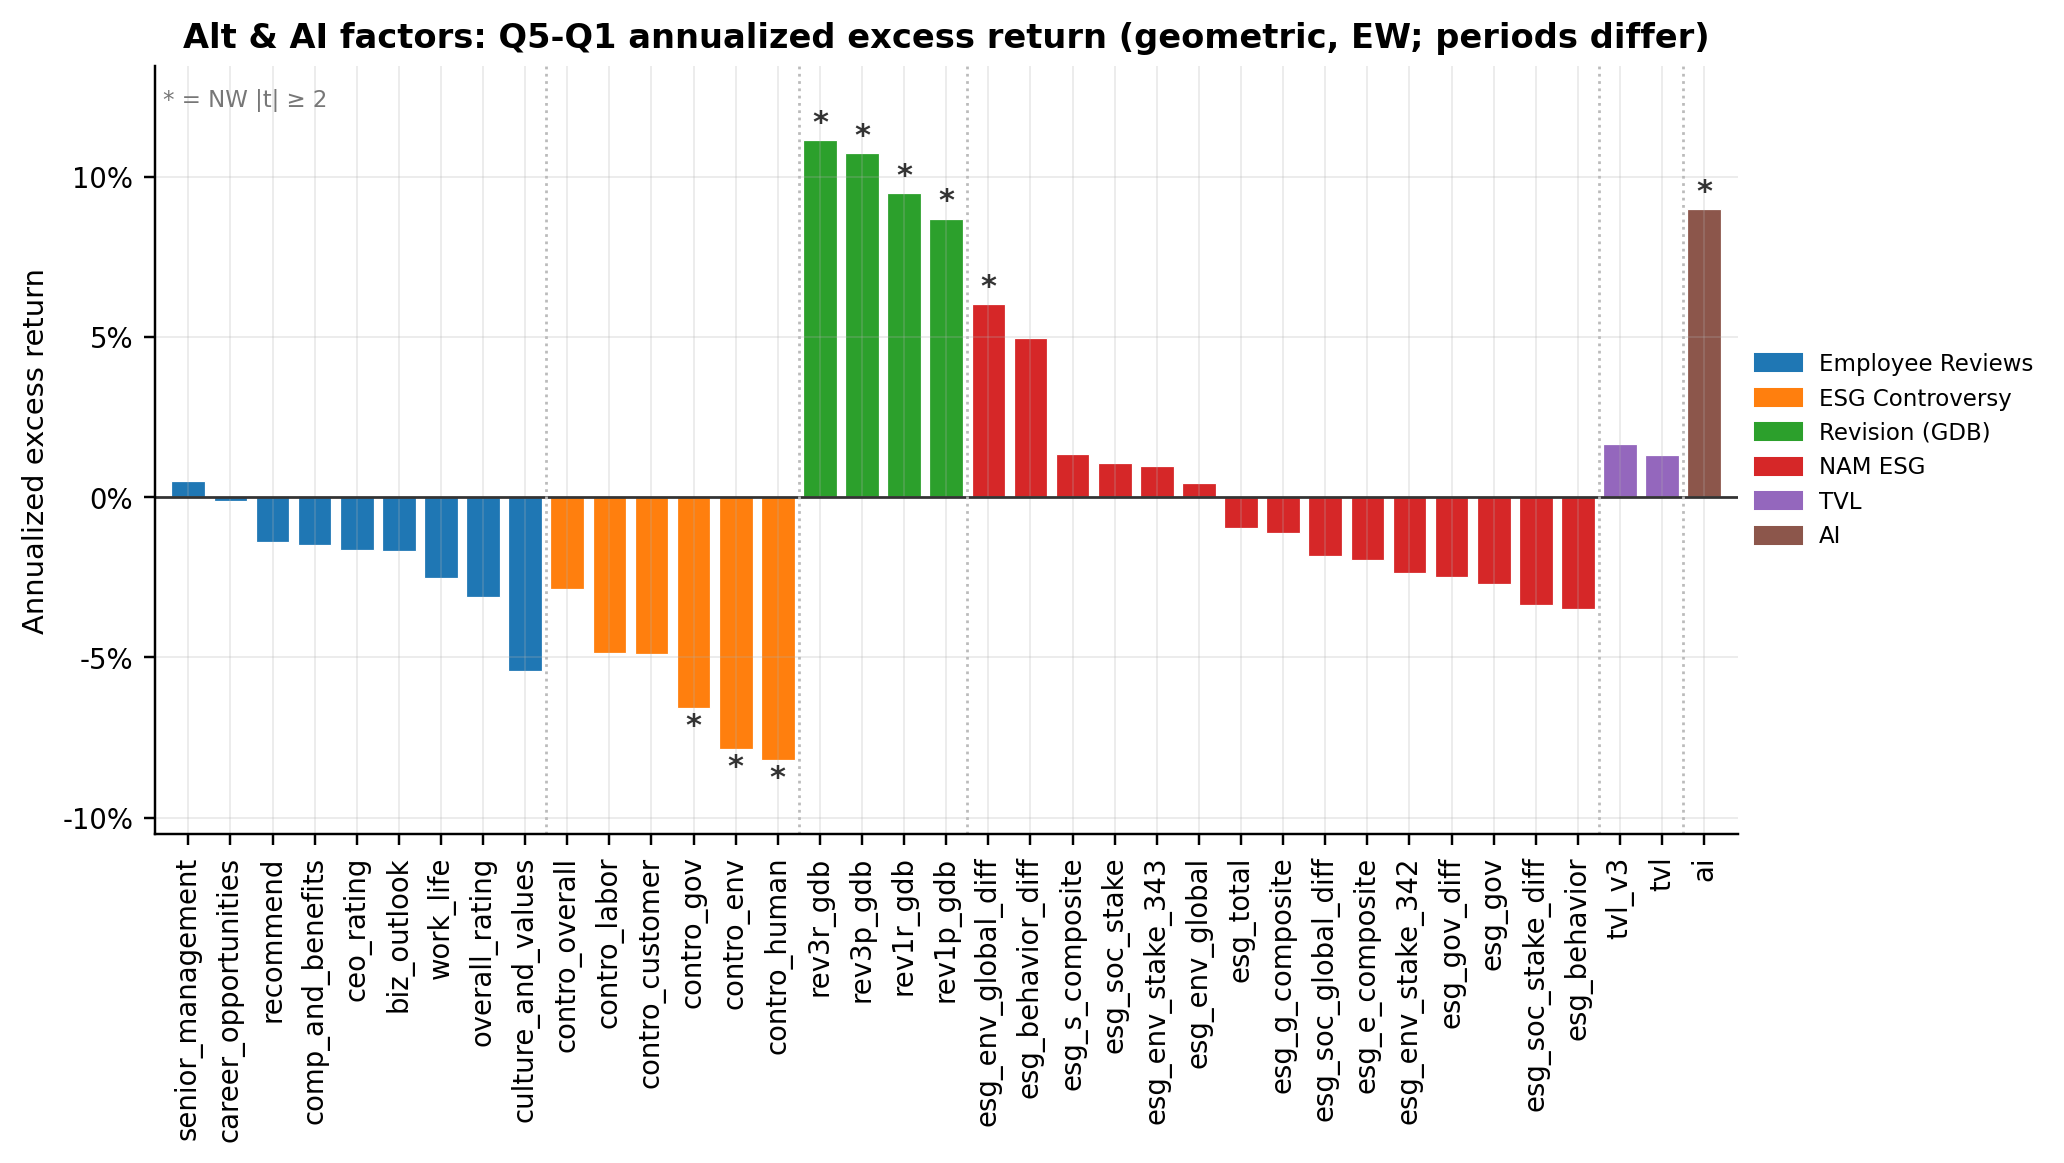

In [5]:
fig = fl.plotting.plot_scoreboard_bars(
    scoreboard, value_col="ls_ann_excess", tstat_col="ls_t_NW",
    title=f"Alt & AI factors: Q{Q}-Q1 annualized excess return (geometric, {WEIGHTING.upper()}; periods differ)")
fl.plotting.savefig(fig, "06_alt_ai/50_alt_scoreboard_ls");

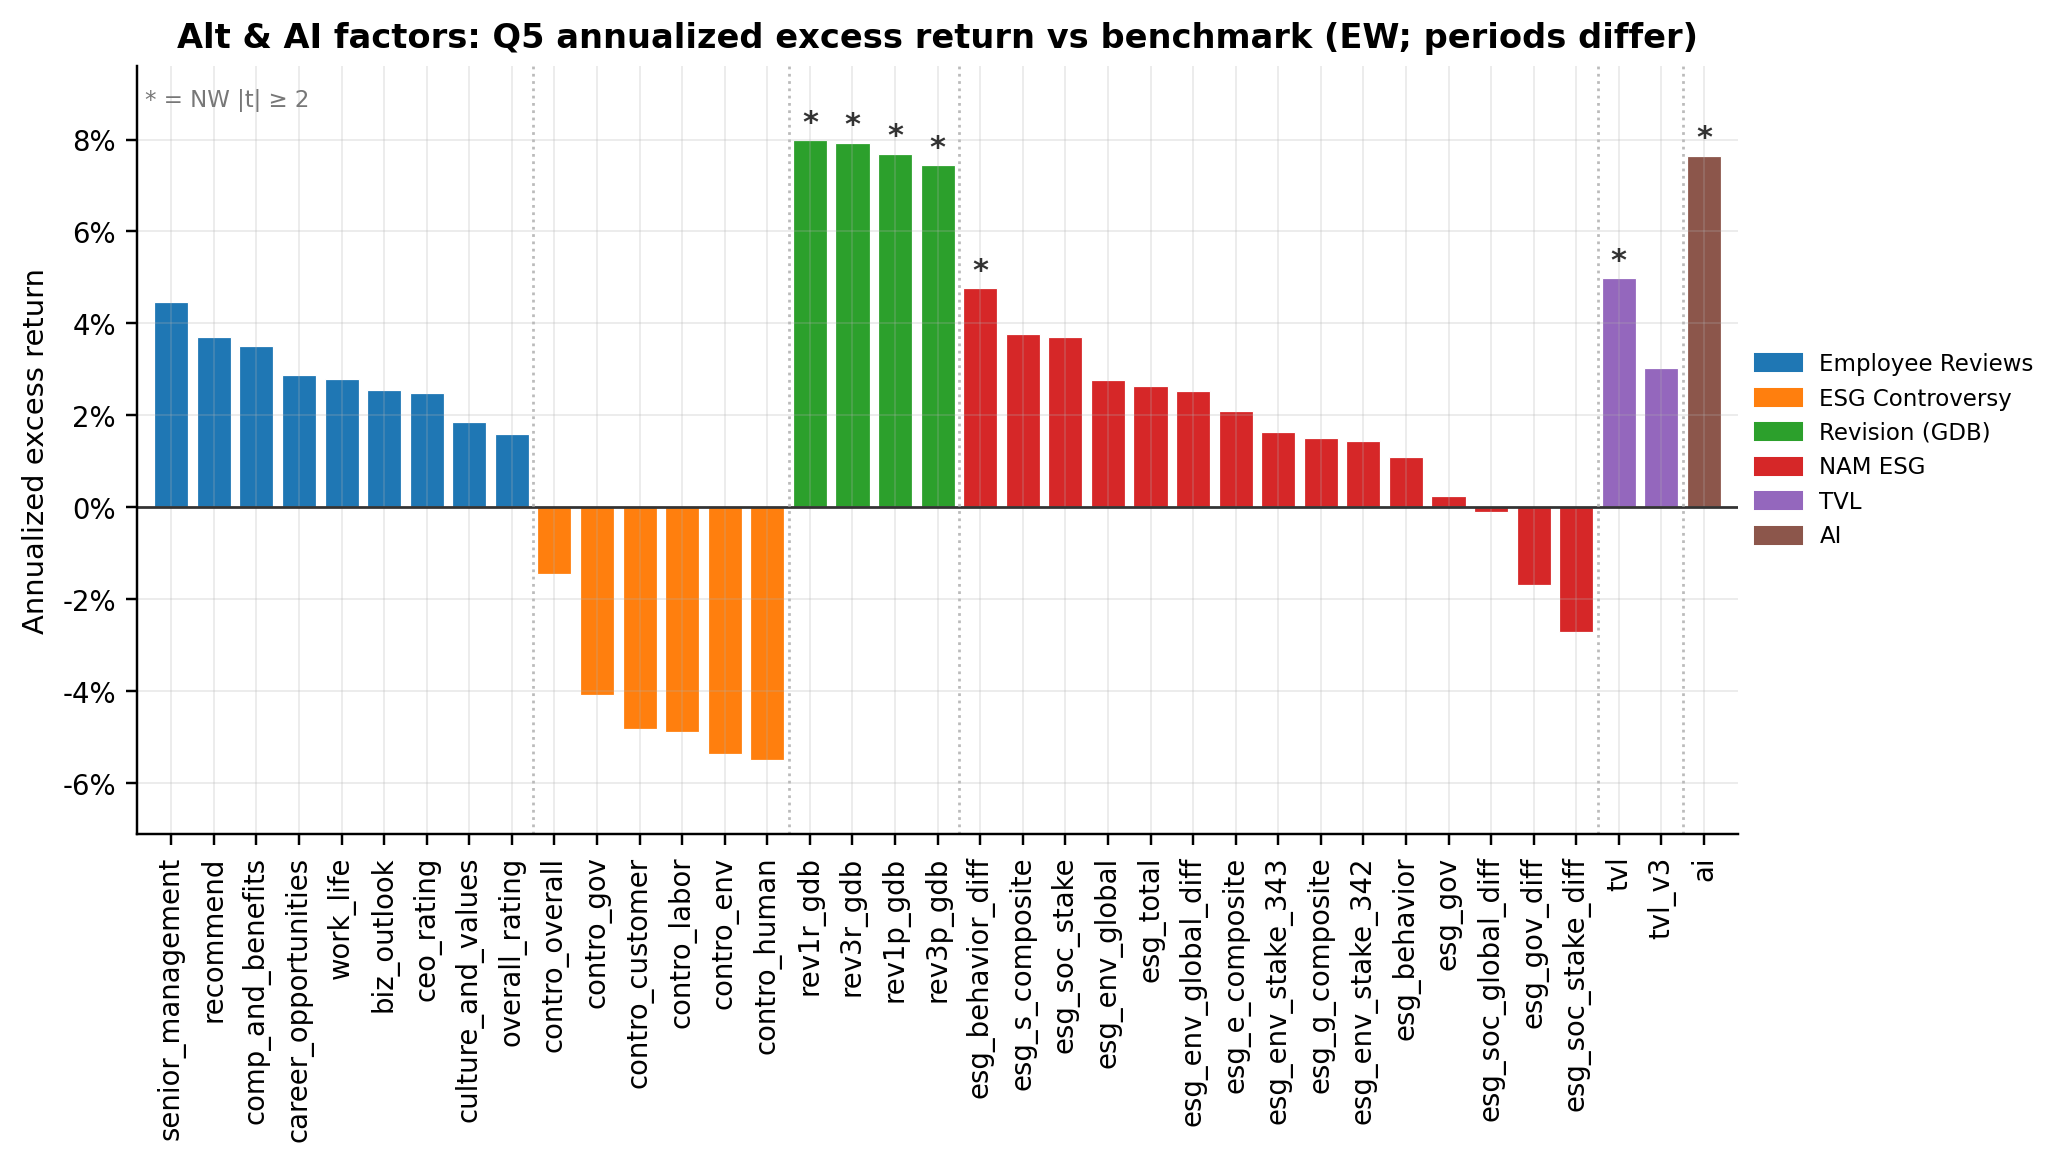

In [6]:
fig = fl.plotting.plot_scoreboard_bars(
    scoreboard, value_col="top_ann_excess", tstat_col="top_t_NW",
    title=f"Alt & AI factors: Q{Q} annualized excess return vs benchmark ({WEIGHTING.upper()}; periods differ)")
fl.plotting.savefig(fig, "06_alt_ai/51_alt_scoreboard_top");

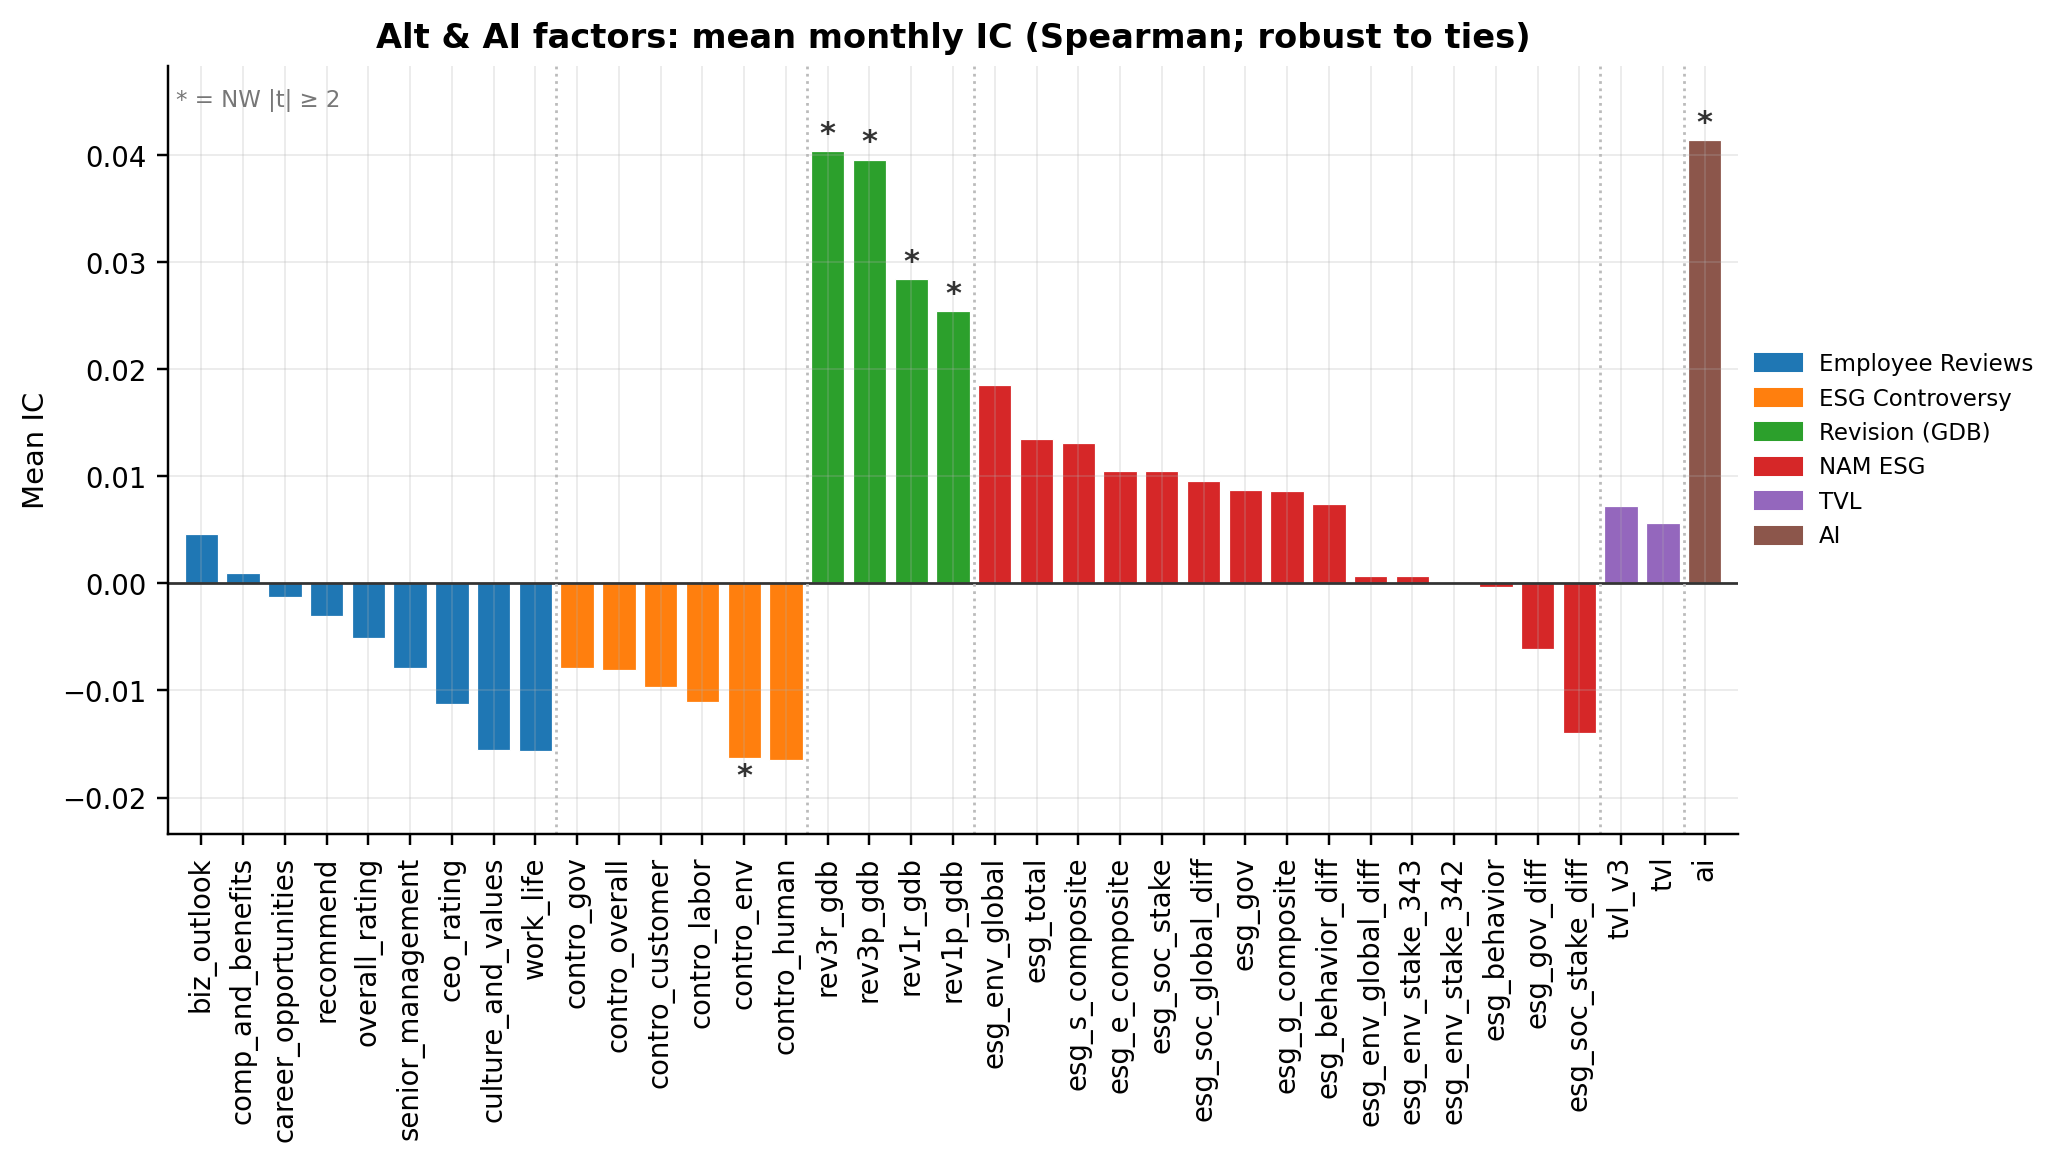

In [7]:
fig = fl.plotting.plot_scoreboard_bars(
    scoreboard, value_col="mean_IC", tstat_col="IC_t_NW",
    title="Alt & AI factors: mean monthly IC (Spearman; robust to ties)",
    ylabel="Mean IC", is_pct=False)
fl.plotting.savefig(fig, "06_alt_ai/52_alt_scoreboard_ic");

## 4. 相関構造

/Users/inu/workspace/india/src/factorlab/multi.py:65: RuntimeWarning: Mean of empty slice
  mu = np.nanmean(z, axis=0)
/Users/inu/workspace/india/.venv/lib/python3.12/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


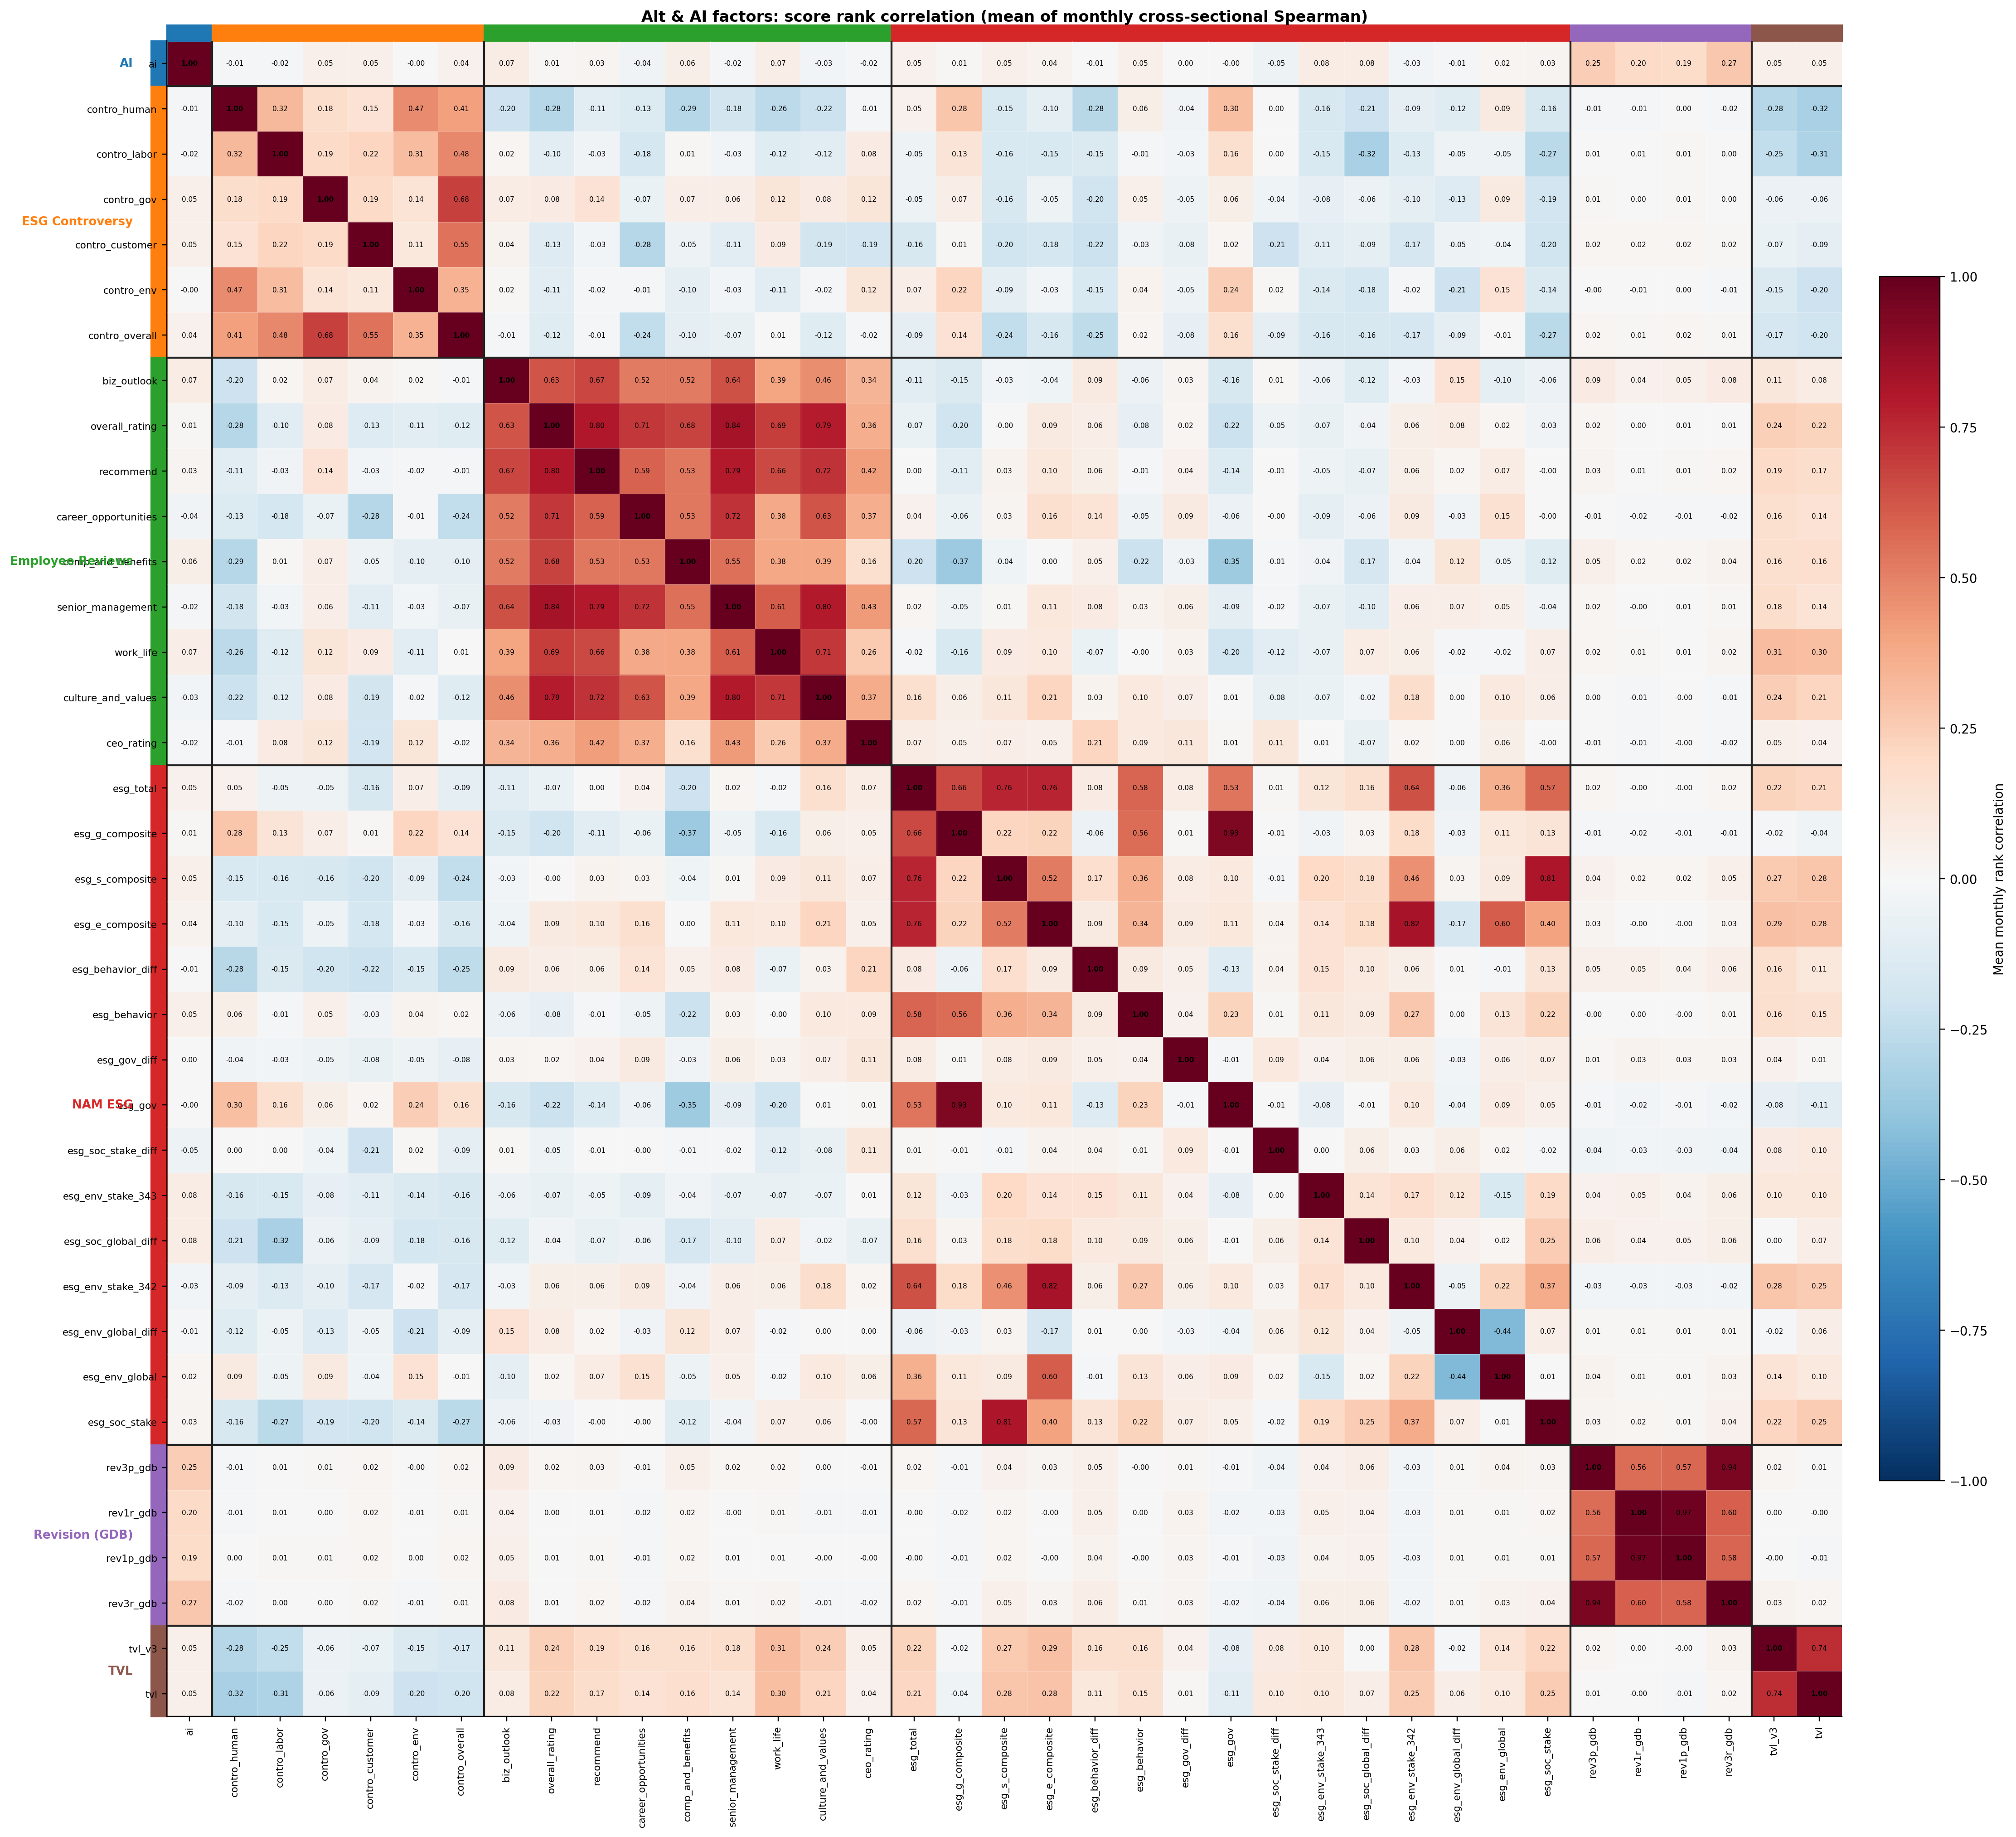

In [8]:
ordered = list(inv.sort_values(["group"]).loc[lambda d: d["column"].isin(ALT_COLS), "column"])
corr_score = fl.multi.cross_sectional_corr(panel, [score_cols[c] for c in ordered], labels=ordered)

fig = fl.plotting.plot_factor_matrix(
    corr_score, groups=groups.reindex(ordered),
    title="Alt & AI factors: score rank correlation (mean of monthly cross-sectional Spearman)",
    off_label="Mean monthly rank correlation",
    off_vmin=-1, off_vmax=1, annotate=True, off_fmt="{:.2f}")
fl.plotting.savefig(fig, "06_alt_ai/53_alt_matrix_score_corr");

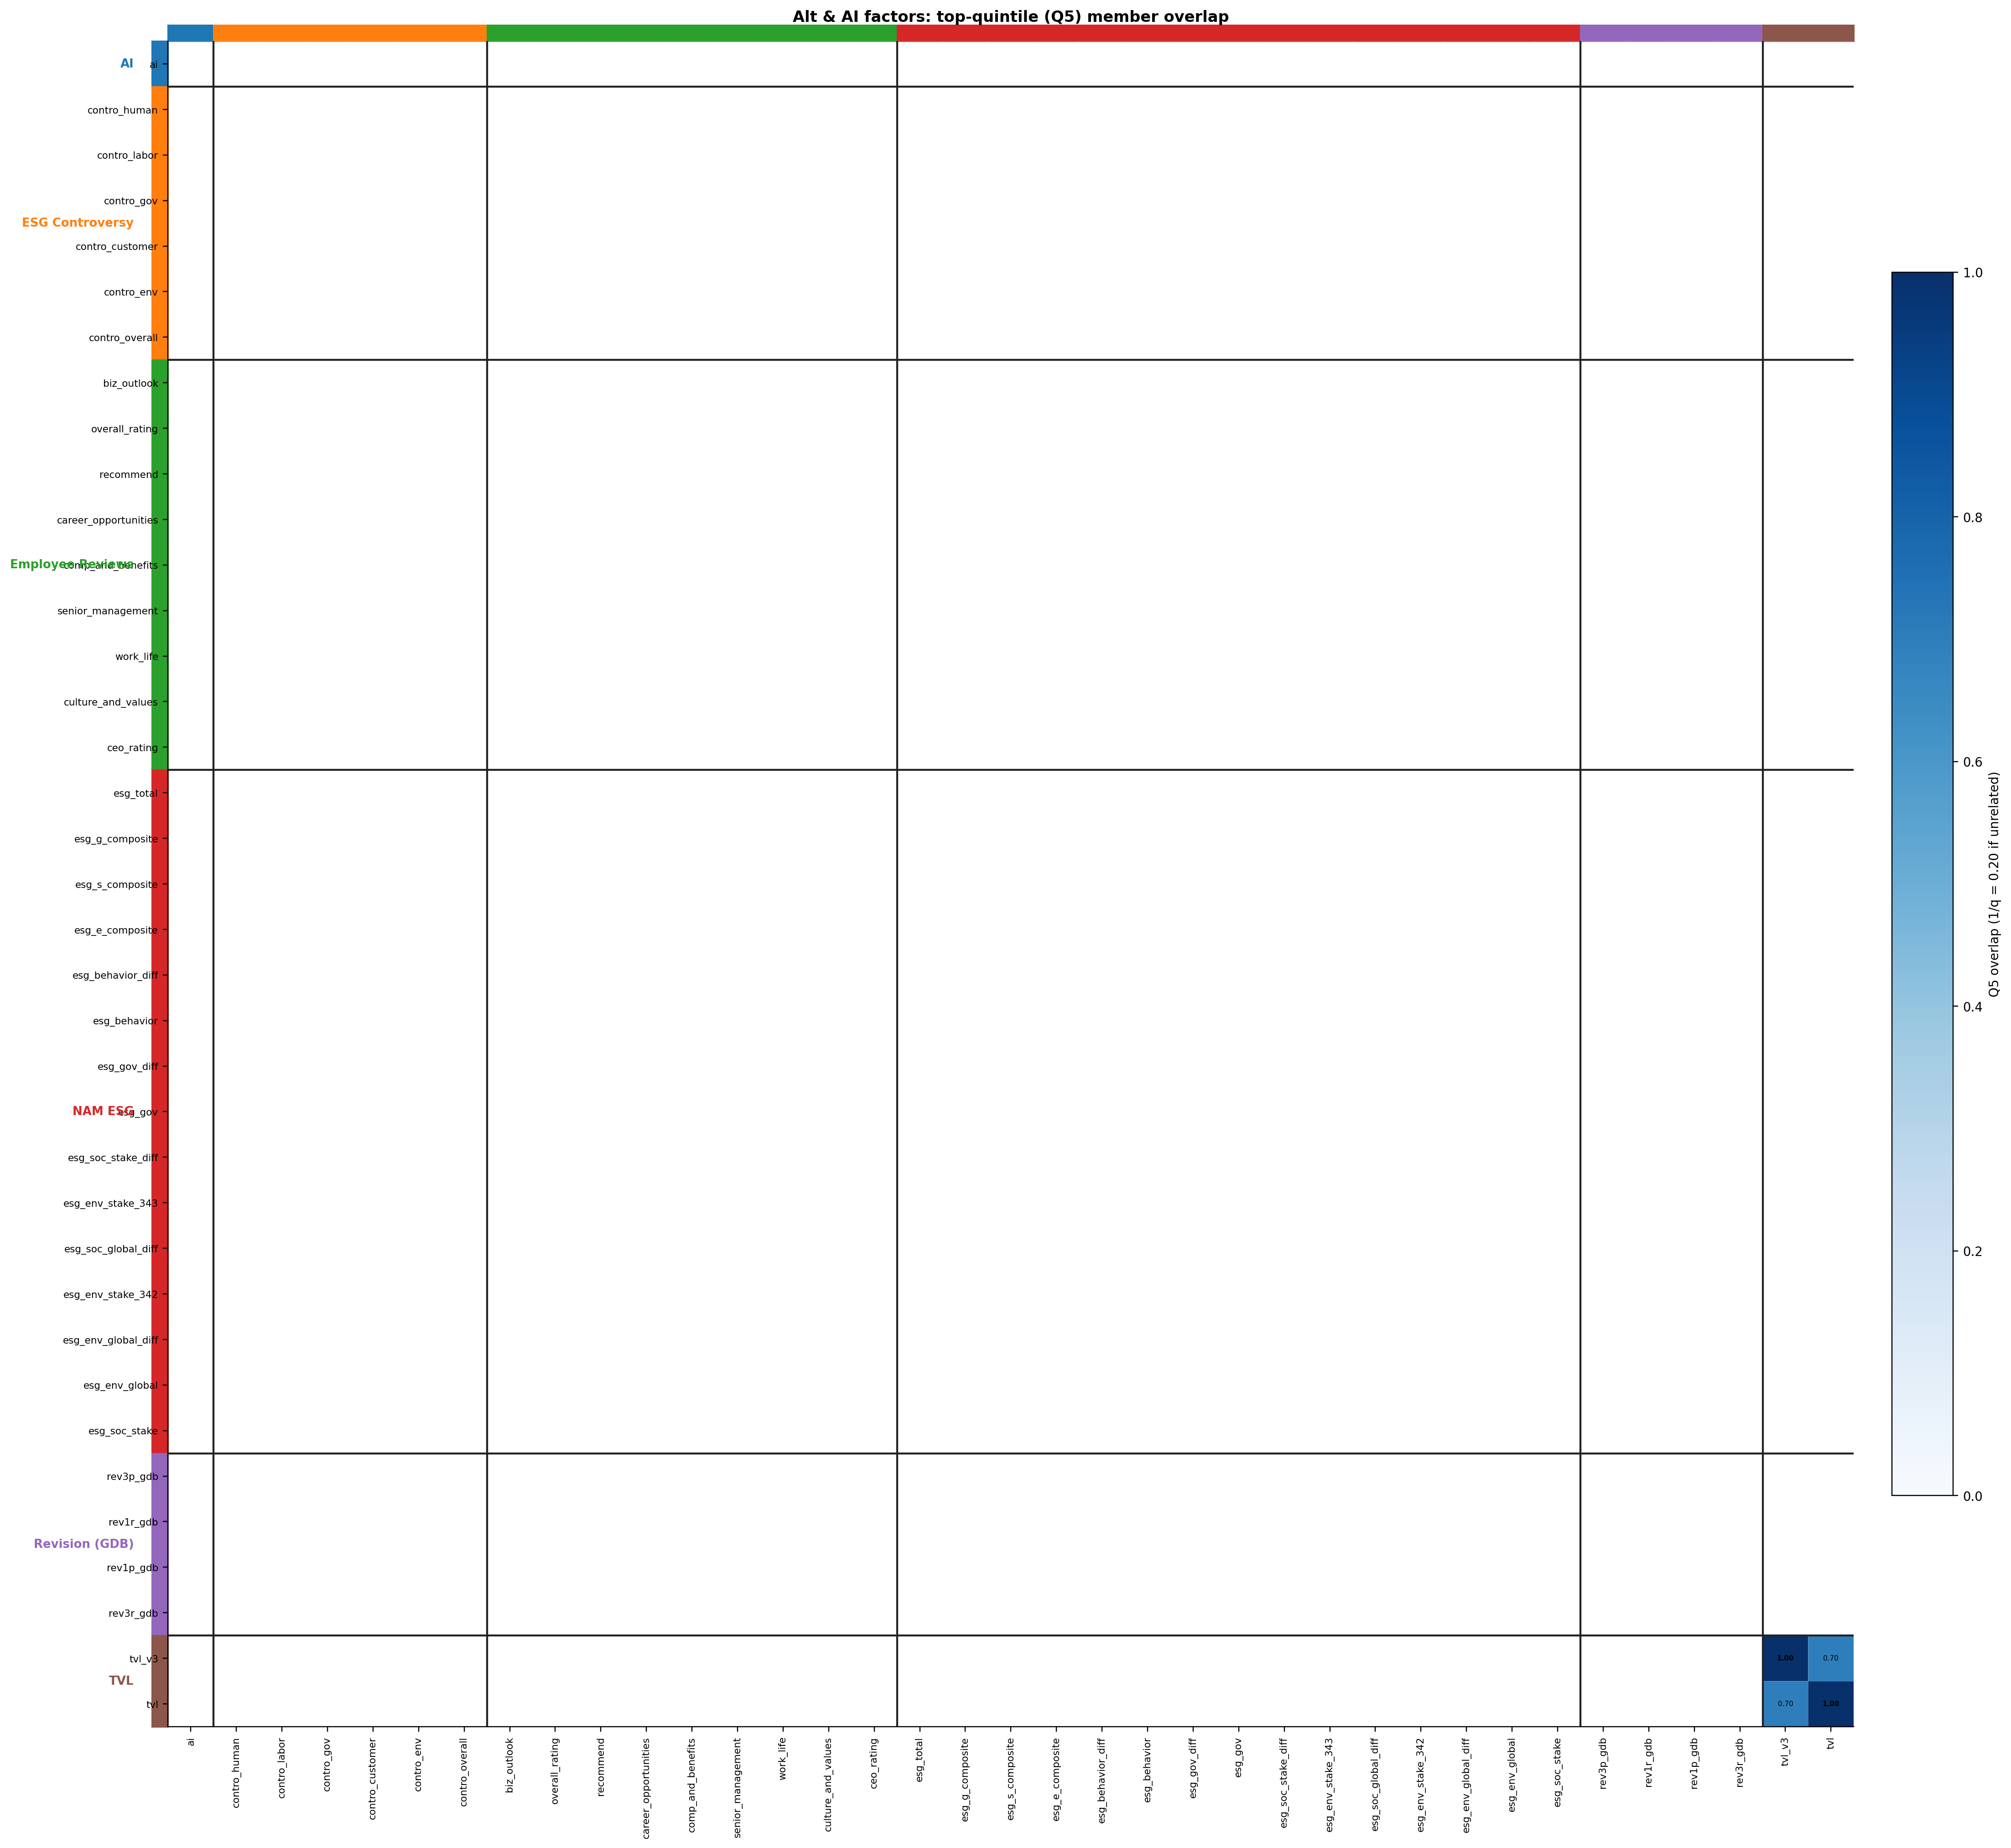

In [9]:
overlap_top = fl.multi.quantile_overlap(panel, [score_cols[c] for c in ordered], q=Q,
                                        which="top", labels=ordered)
fig = fl.plotting.plot_factor_matrix(
    overlap_top, groups=groups.reindex(ordered),
    title=f"Alt & AI factors: top-quintile (Q{Q}) member overlap",
    off_label=f"Q{Q} overlap (1/q = {1/Q:.2f} if unrelated)",
    off_cmap="Blues", off_vmin=0.0, off_vmax=1.0, annotate=True, off_fmt="{:.2f}")
fl.plotting.savefig(fig, "06_alt_ai/54_alt_matrix_overlap");

## 5. AI スコアの深掘り

AI は唯一の日次データかつベンチマーク銘柄をほぼ全カバーするので、単体で詳しく見る。
元々クロスセクション Z スコア（±3.2 クリップ）なので、Blom 化しても順位は変わらない。

In [10]:
AI_START = 201608
ai_panel = panel[panel.index.get_level_values("yyyymm") >= AI_START]

ic_ai = fl.ic.information_coefficient(ai_panel, "ai_blom", "fwd_rtn", method="spearman")
fl.ic.ic_summary(ic_ai).to_frame("AI score").T

,n_months,mean_IC,std_IC,ICIR,ICIR_ann,t_stat,t_stat_NW,hit_ratio,autocorr_1
AI score,117.000,0.041,0.123,0.336,1.165,3.638,3.247,0.598,0.117


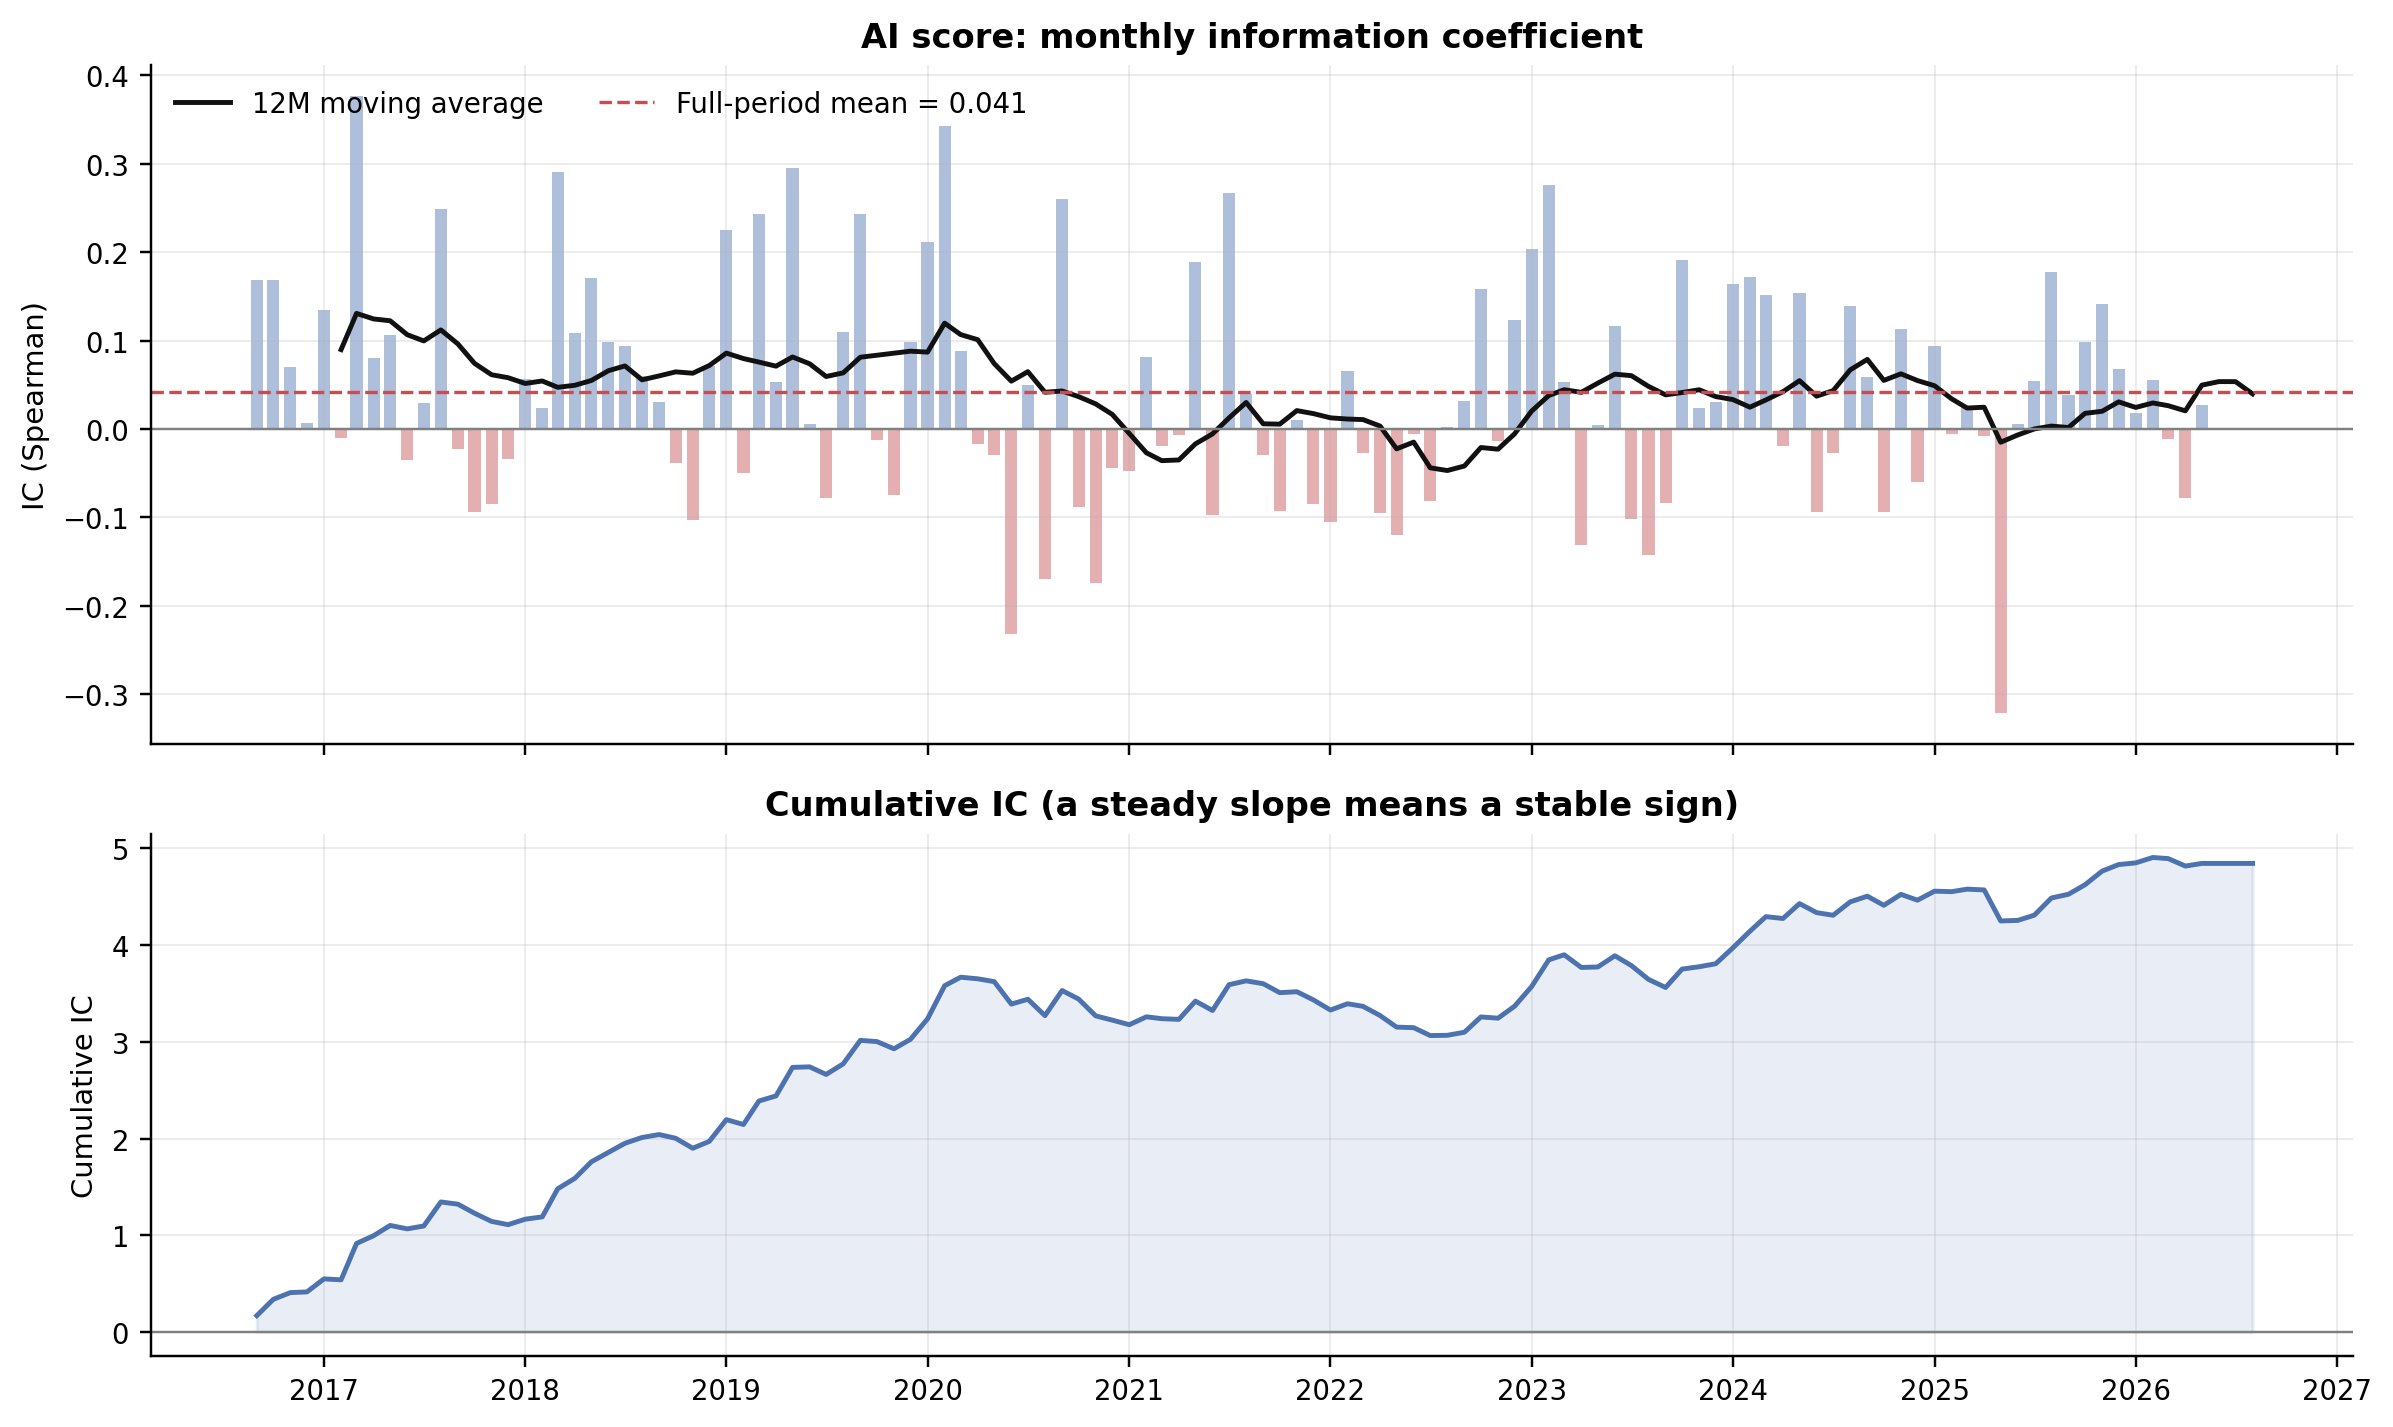

In [11]:
fig = fl.plotting.plot_ic(ic_ai, ma_window=12, factor="AI score", method="Spearman")
fl.plotting.savefig(fig, "06_alt_ai/55_ai_ic_timeseries");

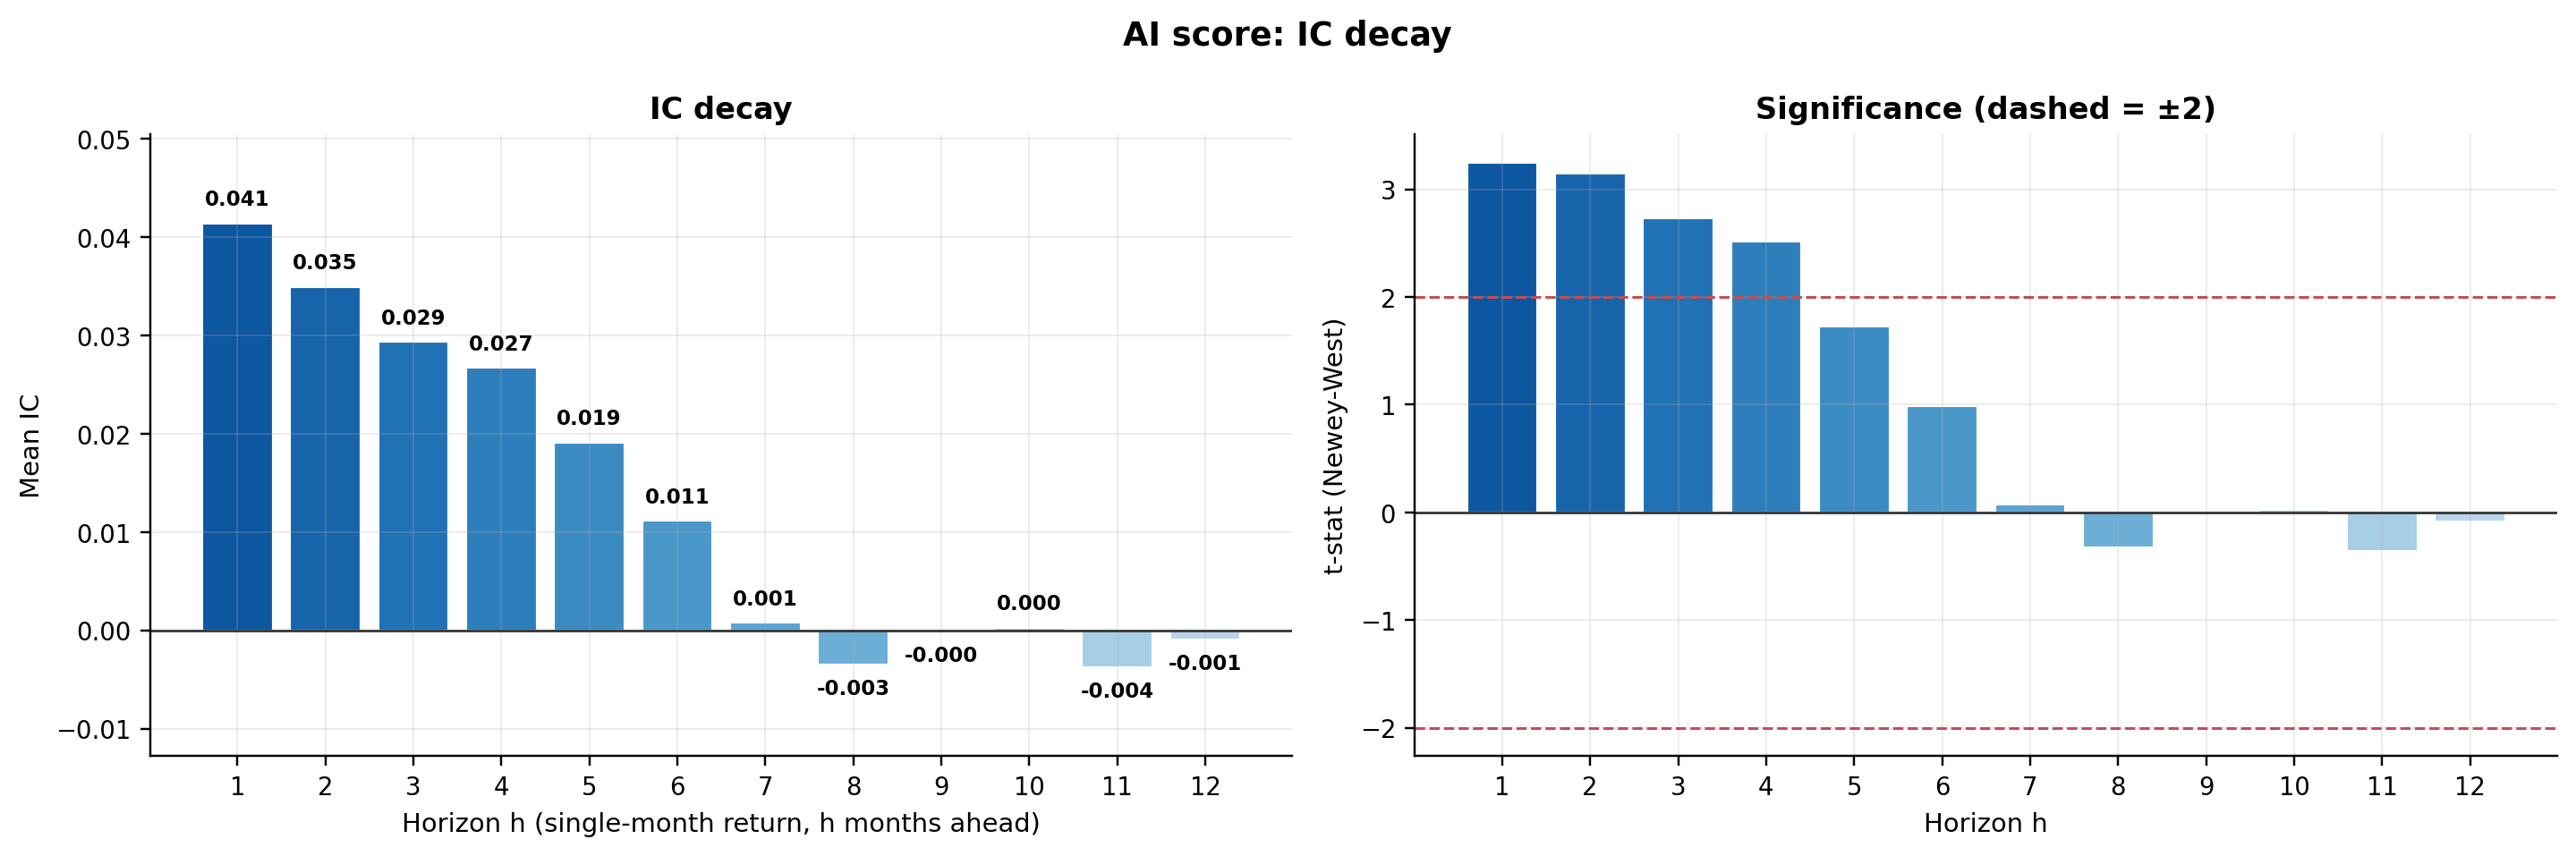

In [12]:
ai_panel = fl.data.add_forward_returns(ai_panel, range(1, 13))
_, decay_ai = fl.ic.ic_decay(ai_panel, "ai_blom", horizons=range(1, 13), method="spearman")
fig = fl.plotting.plot_ic_decay(decay_ai, factor="AI score")
fl.plotting.savefig(fig, "06_alt_ai/56_ai_ic_decay");

In [13]:
res_ai = fl.quantile.quantile_returns(ai_panel, "ai_blom", q=Q, ascending=True, min_universe=MIN_UNIVERSE)
summ_ai = fl.quantile.quantile_summary(res_ai, weighting=WEIGHTING)
summ_ai[["ann_return", "ann_excess", "ann_vol", "te", "IR", "t_stat_NW", "max_dd_excess",
         "turnover_ann", "n_stocks_mean"]]

,ann_return,ann_excess,ann_vol,te,IR,t_stat_NW,max_dd_excess,turnover_ann,n_stocks_mean
Q1,0.091,-0.037,0.235,0.090,-0.230,-0.797,-0.364,3.893,29.325
Q2,0.086,-0.042,0.184,0.056,-0.669,-1.814,-0.316,7.000,29.171
Q3,0.145,0.018,0.183,0.060,0.270,0.877,-0.152,7.709,29.197
Q4,0.155,0.027,0.182,0.060,0.408,1.374,-0.173,7.539,29.171
Q5,0.204,0.076,0.204,0.068,1.052,4.040,-0.063,4.432,29.325
Q5-Q1,0.090,0.090,0.109,0.109,0.845,2.695,-0.195,8.325,NaN
bench,0.128,NaN,0.180,NaN,NaN,NaN,NaN,NaN,NaN


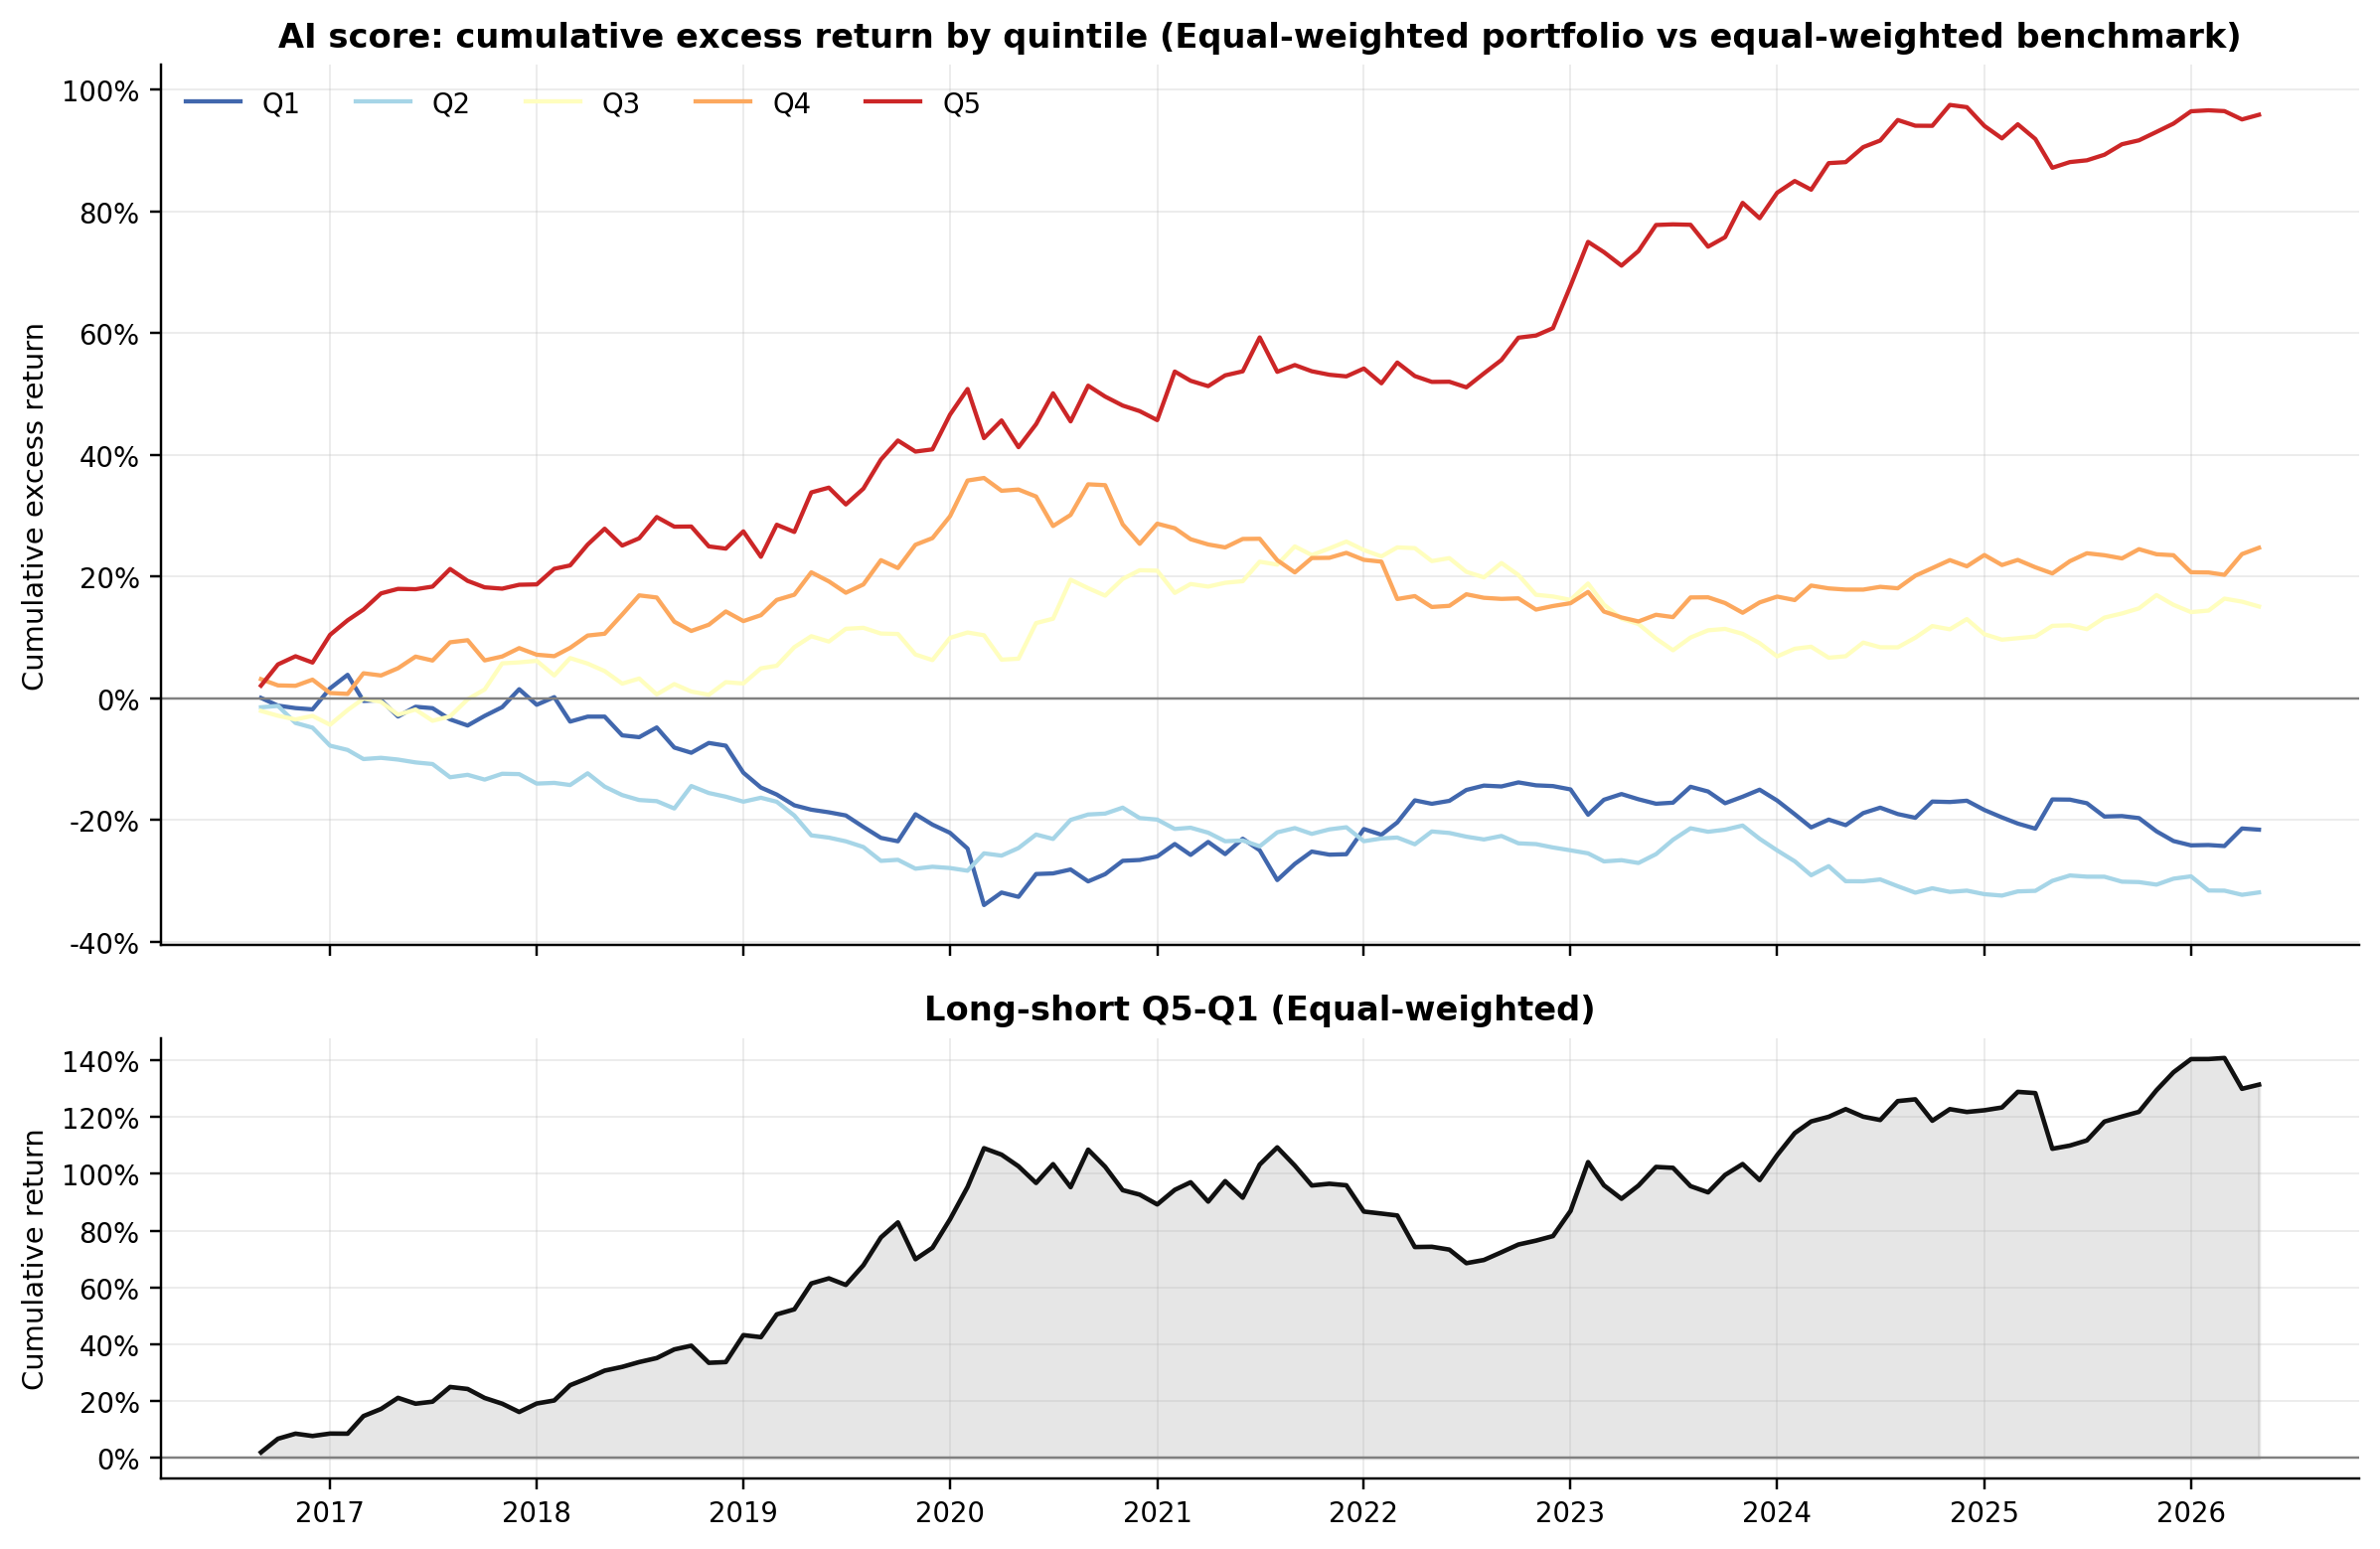

In [14]:
fig = fl.plotting.plot_quantile_timeseries(res_ai, weighting=WEIGHTING, q=Q, factor="AI score")
fl.plotting.savefig(fig, "06_alt_ai/57_ai_quantile_ts");

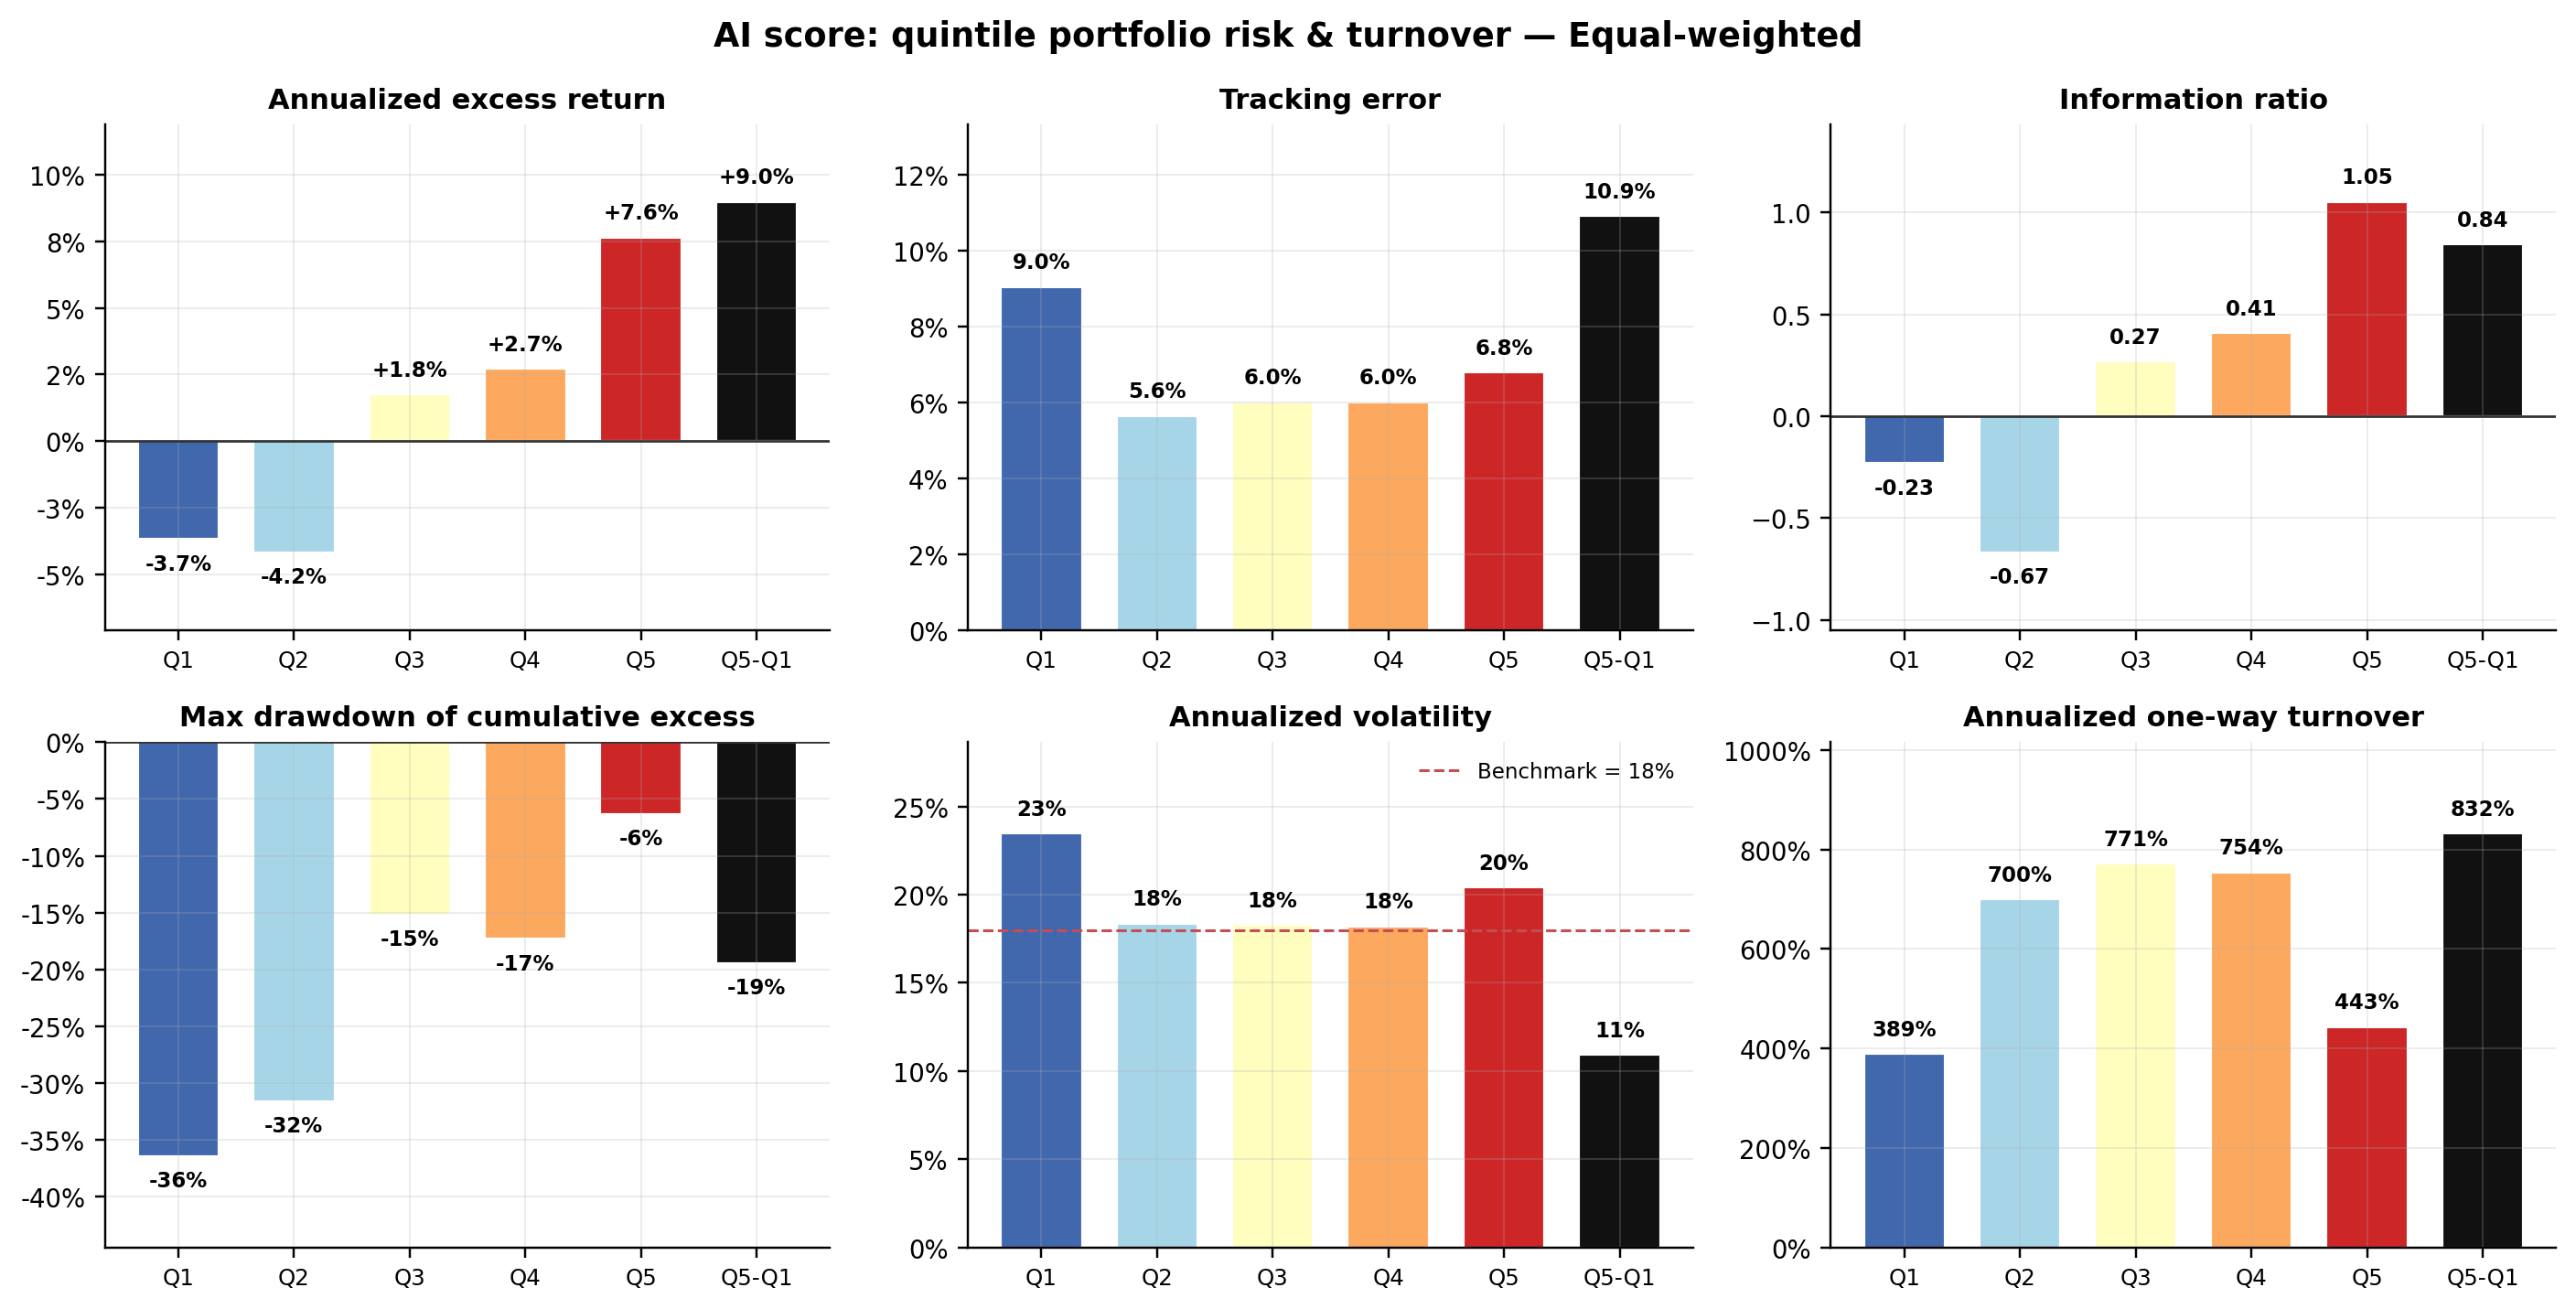

In [15]:
fig = fl.plotting.plot_quantile_dashboard(summ_ai, q=Q, factor="AI score", weighting=WEIGHTING)
fl.plotting.savefig(fig, "06_alt_ai/58_ai_dashboard");

## 6. TVL の長期版（200701〜）

TVL だけは 2007 年からデータがあるので、コアと同じ期間で再確認する。

In [16]:
tvl_panel, _ = fl.altdata.build_alt_panel(factor_ids=[400, 402], include_ai=False,
                                          start=200701, end=END)
tvl_panel, _ = fl.multi.build_scores(tvl_panel, ["tvl", "tvl_v3"], method="blom")
sb_tvl, _ = fl.multi.factor_scoreboard(
    tvl_panel, {"tvl": "tvl_blom", "tvl_v3": "tvl_v3_blom"},
    q=Q, weighting=WEIGHTING, min_universe=MIN_UNIVERSE)
sb_tvl[["ls_ann_excess", "ls_IR", "ls_t_NW", "top_ann_excess", "top_IR", "top_t_NW",
        "mean_IC", "ICIR_ann", "IC_t_NW", "ls_turnover_ann", "n_stocks_mean"]]

,ls_ann_excess,ls_IR,ls_t_NW,top_ann_excess,top_IR,top_t_NW,mean_IC,ICIR_ann,IC_t_NW,ls_turnover_ann,n_stocks_mean
tvl,0.004,0.087,0.336,0.038,0.563,2.093,0.006,0.146,0.705,3.874,37.218
tvl_v3,-0.005,0.014,0.064,0.011,0.227,0.872,0.005,0.156,0.704,4.197,37.525


## 7. rev*_gdb（alt）と core の rev\* の突き合わせ

alt の Revision (GDB) は core の `rev1p`/`rev1r`/`rev3p`/`rev3r` と定義が近いはず。
スコアの順位相関で確認する。

In [17]:
core_rev = ["rev1p", "rev1r", "rev3p", "rev3r"]
core_panel = fl.data.build_panel(core_rev, start=201604, end=END)
core_panel, core_cols = fl.multi.build_scores(core_panel, core_rev, method="blom")
for c in ["rev1p_gdb", "rev1r_gdb", "rev3p_gdb", "rev3r_gdb"]:
    core_panel[c] = panel[f"{c}_blom"].reindex(core_panel.index)

cols = [f"{c}_blom" for c in core_rev] + ["rev1p_gdb", "rev1r_gdb", "rev3p_gdb", "rev3r_gdb"]
labels = core_rev + ["rev1p_gdb", "rev1r_gdb", "rev3p_gdb", "rev3r_gdb"]
cross = fl.multi.cross_sectional_corr(core_panel, cols, labels=labels)
cross.loc[core_rev, ["rev1p_gdb", "rev1r_gdb", "rev3p_gdb", "rev3r_gdb"]]

,rev1p_gdb,rev1r_gdb,rev3p_gdb,rev3r_gdb
rev1p,0.211,0.207,0.269,0.265
rev1r,0.209,0.214,0.261,0.273
rev3p,0.585,0.570,0.744,0.732
rev3r,0.579,0.593,0.720,0.763


## 8. 中立化版（size + sector neutral）

コア（Step 5 §7）と同じ規約で alt / AI を中立化し、Q5 年率超過とスコア相関行列のみを見る。
AI はカバレッジが大型に限られるため、サイズ中立化の影響が特に出やすい点に注意。

In [18]:
panel, _ = fl.multi.build_scores(panel, ALT_COLS, method="blom",
                                 group_col="sector", control_cols=["log_cap"],
                                 suffix="_blom_ss")
score_cols_ss = {c: f"{c}_blom_ss" for c in ALT_COLS}

sb_ss, _ = fl.multi.factor_scoreboard(panel, score_cols_ss, groups=groups, q=Q,
                                      weighting=WEIGHTING, min_universe=MIN_UNIVERSE)
pd.DataFrame({"raw": scoreboard["top_ann_excess"], "size_sector": sb_ss["top_ann_excess"],
              "raw_t": scoreboard["top_t_NW"], "ss_t": sb_ss["top_t_NW"]}) \
    .sort_values("size_sector", ascending=False).head(12)

,raw,size_sector,raw_t,ss_t
rev3p_gdb,0.074,0.078,2.655,2.769
rev3r_gdb,0.079,0.077,2.822,2.762
rev1r_gdb,0.080,0.075,2.917,2.858
rev1p_gdb,0.077,0.070,2.698,2.757
tvl,0.050,0.064,2.506,2.679
tvl_v3,0.030,0.056,1.687,2.397
ai,0.076,0.050,4.040,2.553
esg_s_composite,0.038,0.046,1.881,2.148
comp_and_benefits,0.035,0.042,1.400,1.960
esg_behavior_diff,0.048,0.042,2.428,1.724


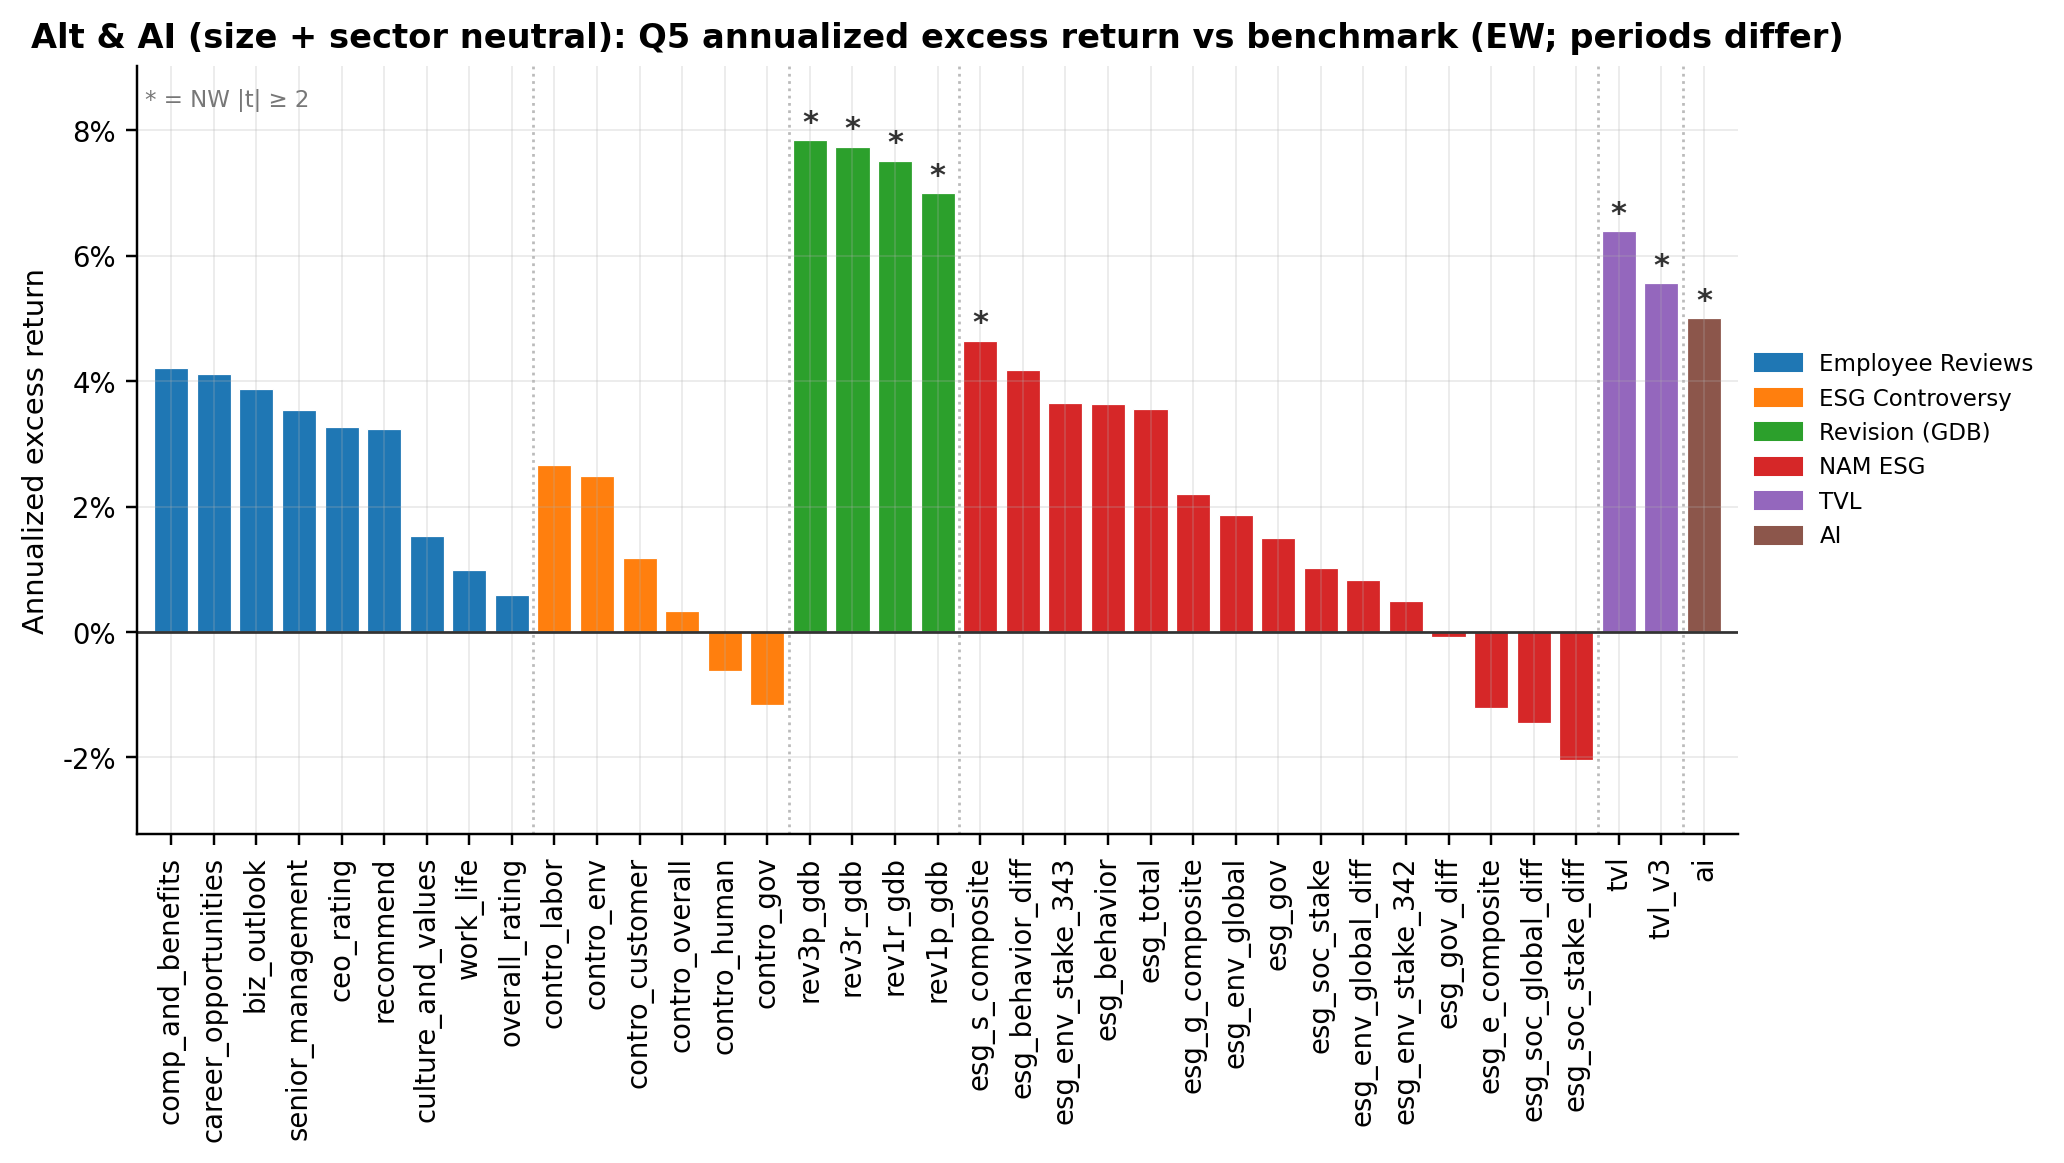

In [19]:
fig = fl.plotting.plot_scoreboard_bars(
    sb_ss, value_col="top_ann_excess", tstat_col="top_t_NW",
    title=f"Alt & AI (size + sector neutral): Q{Q} annualized excess return vs benchmark ({WEIGHTING.upper()}; periods differ)")
fl.plotting.savefig(fig, "06_alt_ai/59_alt_scoreboard_top_neutral");

/Users/inu/workspace/india/src/factorlab/multi.py:65: RuntimeWarning: Mean of empty slice
  mu = np.nanmean(z, axis=0)
/Users/inu/workspace/india/.venv/lib/python3.12/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


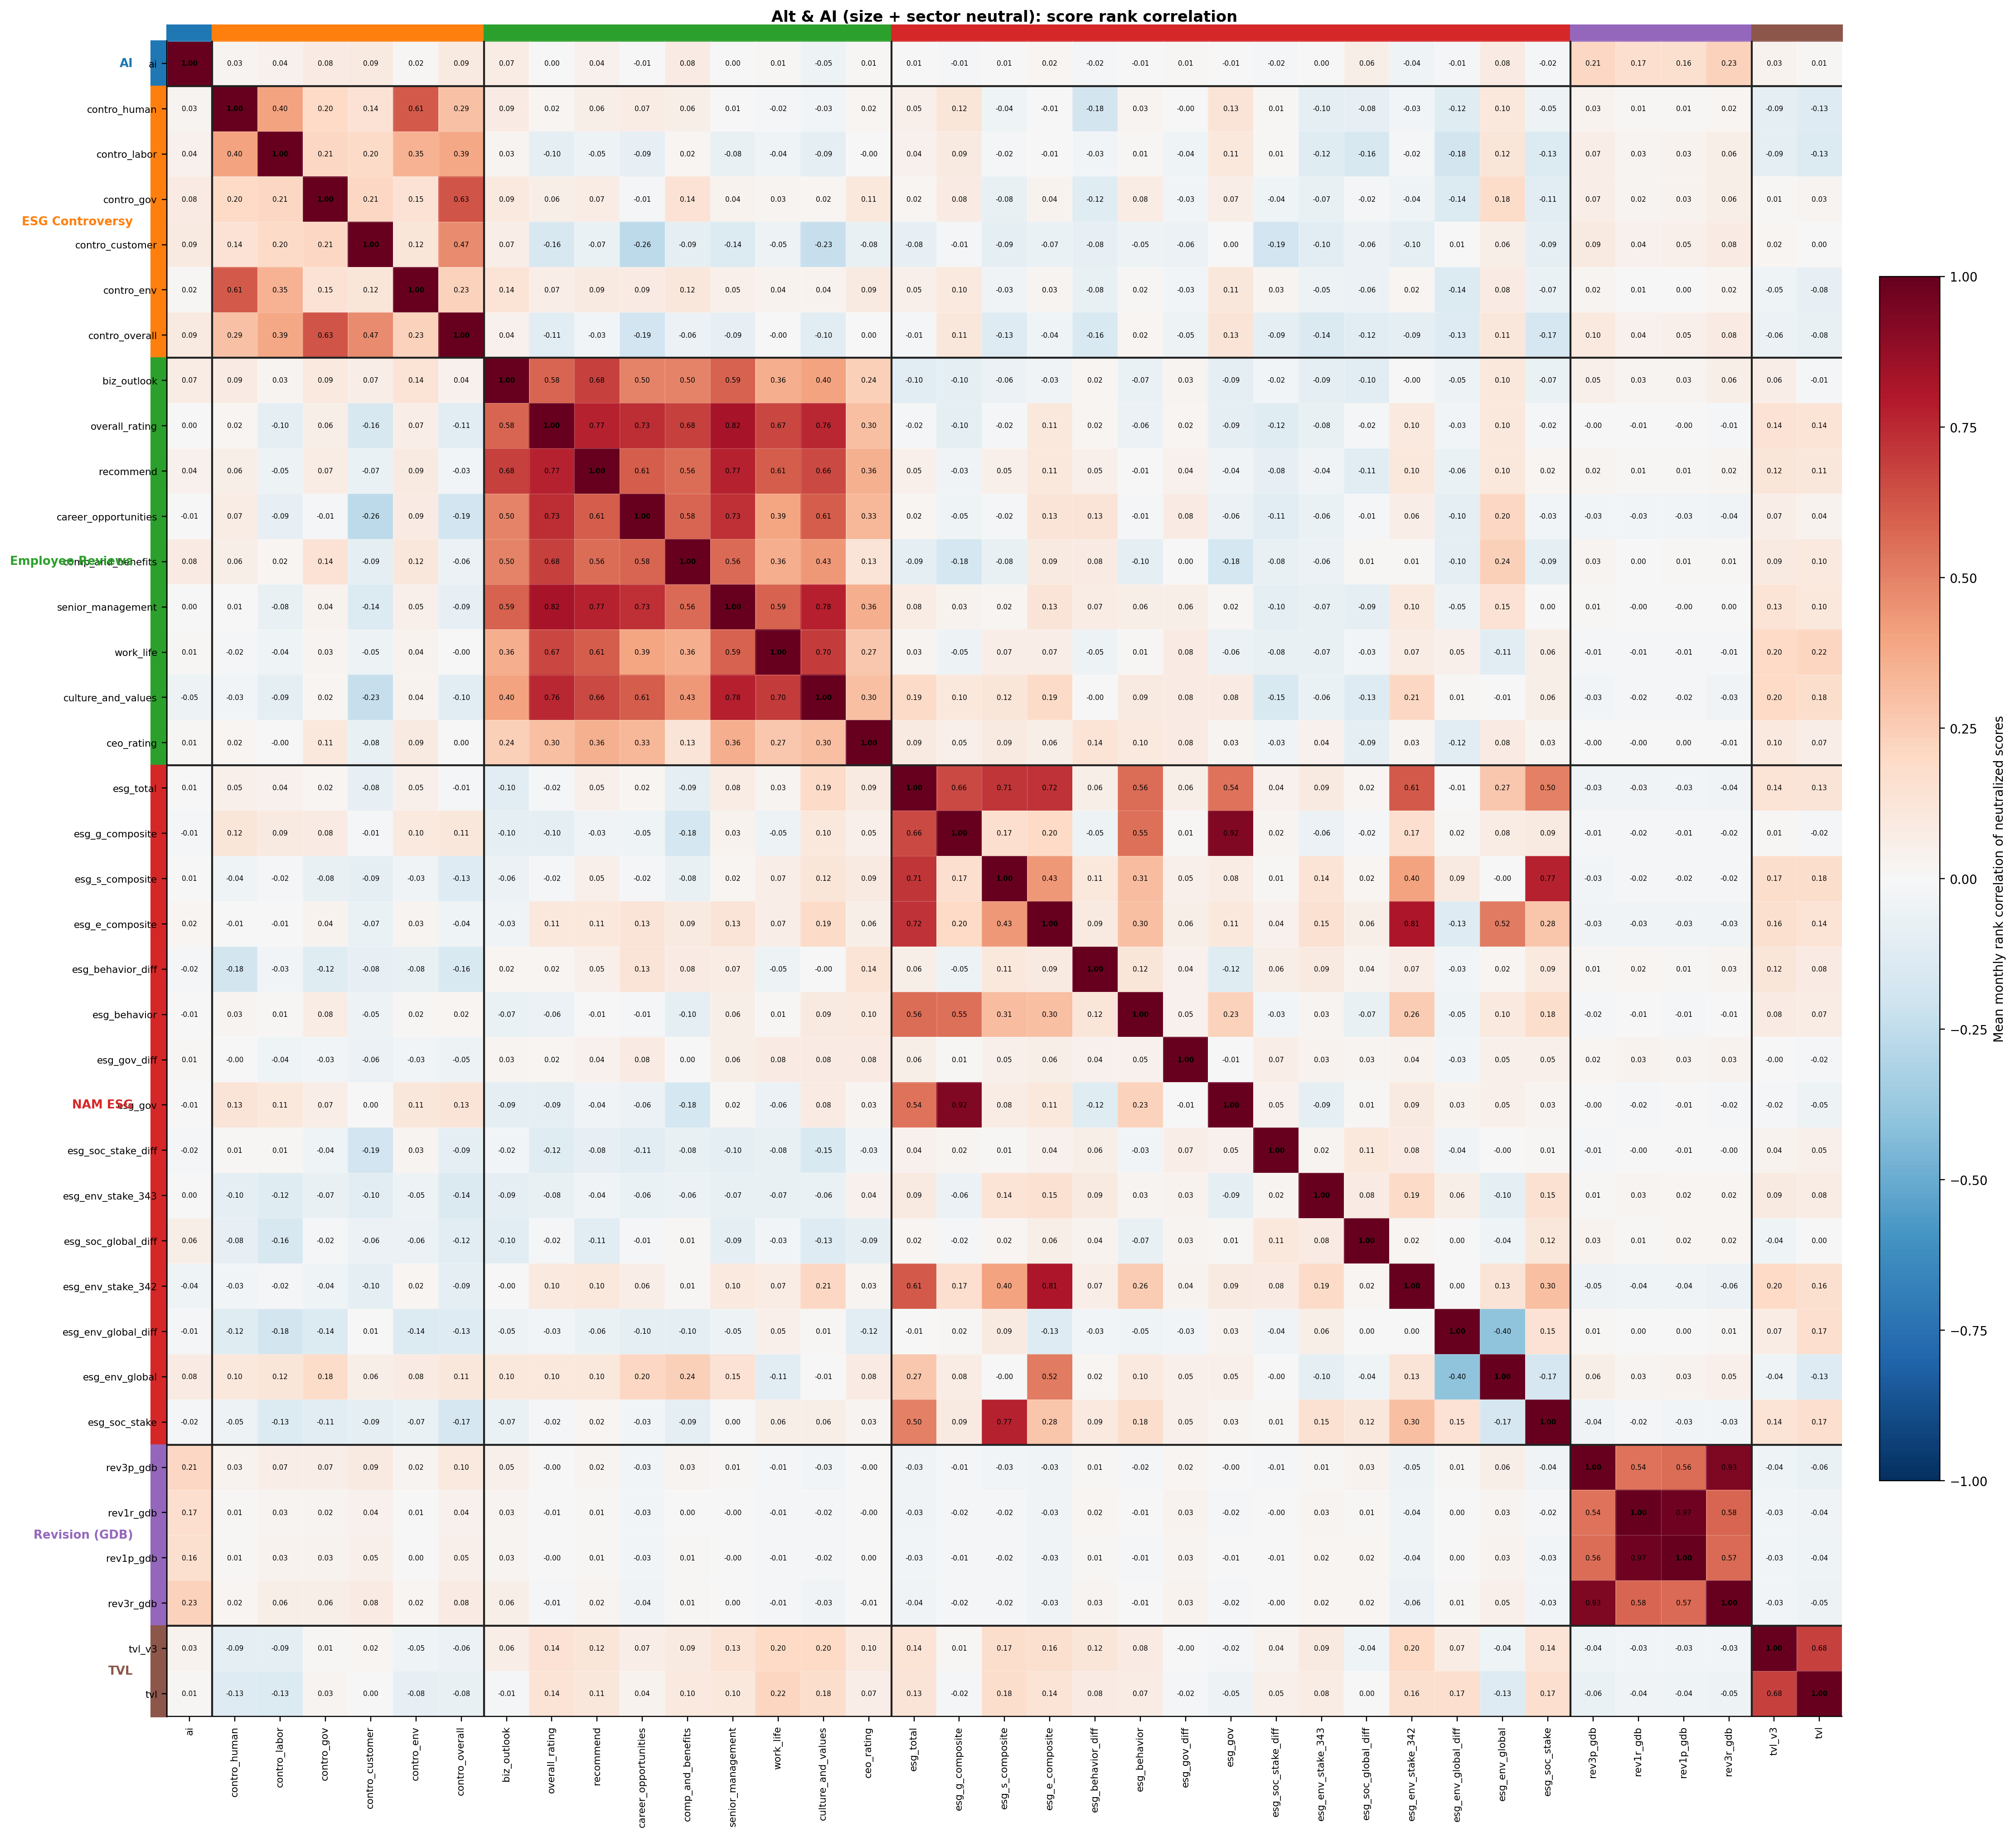

In [20]:
corr_ss = fl.multi.cross_sectional_corr(panel, [score_cols_ss[c] for c in ordered], labels=ordered)
fig = fl.plotting.plot_factor_matrix(
    corr_ss, groups=groups.reindex(ordered),
    title="Alt & AI (size + sector neutral): score rank correlation",
    off_label="Mean monthly rank correlation of neutralized scores",
    off_vmin=-1, off_vmax=1, annotate=True, off_fmt="{:.2f}")
fl.plotting.savefig(fig, "06_alt_ai/5A_alt_matrix_corr_neutral");

---

## まとめの観点

- alt / AI は**期間・カバレッジ・離散度がバラバラ**なので、コアの100本と同じ棒グラフに
  並べる前に、この特性表（§2）で「その数字がどれだけ信用できるか」を確認する
- コントラバーシー系の Q5−Q1 はタイ割れの影響を受けるため、IC を主に読む
- AI・NAM ESG はベンチマーク銘柄カバレッジがほぼ100%なので、
  大型株ユニバースでの実装に直結する